# Optimalisasi 15 Fitur Teknikal IHSG

**Studi kasus:** membangun pipeline fitur, membandingkan tiga konfigurasi window, dan memilih konfigurasi tanpa menggunakan data uji.

**Instrumen:** Indeks Harga Saham Gabungan, ticker Yahoo Finance `^JKSE`.

**Luaran notebook:**

1. Data Dictionary untuk 15 fitur.
2. Pipeline fitur yang kausal dan dapat direproduksi.
3. Tabel warm-up teoretis dan aktual.
4. Perbandingan tiga konfigurasi window.
5. Laporan korelasi, VIF, dan risiko redundansi.
6. Berkas CSV serta laporan teks di `/kaggle/working/ihsg_feature_study`.

Setiap tahap diakhiri dengan **tabel, grafik, atau status pemeriksaan**. Dengan demikian, pengguna dapat membaca hasil secara bertahap dan segera mengetahui jika data atau logika program bermasalah.

> Catatan: notebook ini digunakan untuk pembelajaran dan riset. Hasilnya bukan rekomendasi investasi.

## A. Algoritma Program

1. **Ambil data IHSG.** Baca CSV dari Kaggle Input jika tersedia. Jika tidak, unduh data `^JKSE` melalui `yfinance`.
2. **Validasi data.** Standarkan nama kolom, urutkan tanggal, hapus tanggal ganda, dan periksa konsistensi OHLCV.
3. **Kunci data uji.** Bagi data secara kronologis menjadi train 70%, validation 15%, dan test 15%. Data test tidak digunakan untuk analisis konfigurasi.
4. **Definisikan tiga konfigurasi.** Gunakan window pendek, menengah, dan panjang untuk tren, momentum, volatilitas, serta signal.
5. **Bangun 15 fitur.** Hitung indikator hanya dengan data saat ini dan masa lalu.
6. **Bentuk target.** Gunakan arah log return satu hari ke depan. Fitur pada hari ke-\(t\) memprediksi arah return hari ke-\(t+1\).
7. **Analisis warm-up.** Hitung jumlah observasi awal yang belum memiliki nilai untuk setiap fitur.
8. **Validasi deret waktu.** Uji setiap konfigurasi dengan expanding-window cross-validation pada train.
9. **Uji validation.** Latih model pada train dan nilai pada validation.
10. **Audit redundansi.** Hitung korelasi absolut, Variance Inflation Factor, dan fitur konstan hanya pada train.
11. **Pilih konfigurasi.** Utamakan balanced accuracy validation, lalu ROC-AUC, jumlah redundansi, dan warm-up.
12. **Ekspor hasil.** Simpan Data Dictionary, fitur, warm-up, metrik, dan laporan risiko.
13. **Pertahankan test tetap terkunci.** Evaluasi test hanya boleh dilakukan setelah konfigurasi final dibekukan dan sakelar dibuka secara sadar.

In [1]:
# OUTPUT TAHAP A: peta algoritma dan keputusan utama
import pandas as pd
from IPython.display import display

algorithm_steps = pd.DataFrame(
    [
        (1, "Akuisisi", "Baca CSV atau unduh ^JKSE", "Data OHLCV mentah"),
        (2, "Validasi", "Periksa tanggal, OHLC, volume, dan NaN", "Laporan kualitas"),
        (3, "Split waktu", "Pisahkan 70% train, 15% validation, 15% test", "Test Vault terkunci"),
        (4, "Feature engineering", "Hitung 15 indikator secara kausal", "Tiga feature set"),
        (5, "Warm-up", "Ukur baris awal yang belum valid", "Tabel kehilangan sampel"),
        (6, "Cross-validation", "Expanding window dengan gap satu hari", "Metrik CV"),
        (7, "Validation", "Bandingkan tiga konfigurasi", "Peringkat window"),
        (8, "Redundansi", "Audit korelasi, VIF, dan fitur konstan", "Laporan risiko"),
        (9, "Keputusan", "Bekukan konfigurasi terbaik", "Kandidat final"),
        (10, "Test final", "Buka satu kali setelah keputusan dibekukan", "Evaluasi out-of-sample"),
    ],
    columns=["Tahap", "Proses", "Aktivitas", "Output"],
)
print("OUTPUT TAHAP A: urutan algoritma program")
display(algorithm_steps)

OUTPUT TAHAP A: urutan algoritma program


,Tahap,Proses,Aktivitas,Output
0,1,Akuisisi,Baca CSV atau unduh ^JKSE,Data OHLCV mentah
1,2,Validasi,"Periksa tanggal, OHLC, volume, dan NaN",Laporan kualitas
2,3,Split waktu,"Pisahkan 70% train, 15% validation, 15% test",Test Vault terkunci
3,4,Feature engineering,Hitung 15 indikator secara kausal,Tiga feature set
4,5,Warm-up,Ukur baris awal yang belum valid,Tabel kehilangan sampel
5,6,Cross-validation,Expanding window dengan gap satu hari,Metrik CV
6,7,Validation,Bandingkan tiga konfigurasi,Peringkat window
7,8,Redundansi,"Audit korelasi, VIF, dan fitur konstan",Laporan risiko
8,9,Keputusan,Bekukan konfigurasi terbaik,Kandidat final
9,10,Test final,Buka satu kali setelah keputusan dibekukan,Evaluasi out-of-sample


## B. Pseudocode

```text
INPUT: data OHLCV IHSG, tiga konfigurasi window

LOAD data IHSG
STANDARDIZE nama kolom dan indeks tanggal
ASSERT data kronologis, unik, positif, dan OHLC konsisten

SPLIT raw_data secara waktu:
    train      = 70% pertama
    validation = 15% berikutnya
    test_vault = 15% terakhir

LOCK test_vault

FOR setiap konfigurasi window:
    CALCULATE 15 fitur dengan rolling/expanding masa lalu
    CALCULATE target arah log return t+1
    MEASURE warm-up setiap fitur

    X_train, y_train = bagian train yang lengkap
    X_valid, y_valid = bagian validation yang lengkap

    RUN TimeSeriesSplit pada train
    FIT scaler dan logistic regression di setiap fold
    SCORE balanced accuracy dan ROC-AUC

    FIT ulang pada seluruh train
    SCORE validation

    CALCULATE korelasi, VIF, dan pasangan redundan dari X_train
    STORE semua hasil
END FOR

RANK konfigurasi:
    1. balanced accuracy validation tertinggi
    2. ROC-AUC validation tertinggi
    3. pasangan redundan paling sedikit
    4. warm-up paling pendek

EXPORT seluruh tabel dan laporan
KEEP test_vault locked
```

In [2]:
# OUTPUT TAHAP B: aturan kontrol yang diterjemahkan dari pseudocode
pseudocode_controls = pd.DataFrame(
    {
        "Kontrol": [
            "Urutan waktu",
            "Kausalitas fitur",
            "Scaling",
            "Pemilihan window",
            "Audit redundansi",
            "Akses data test",
        ],
        "Aturan": [
            "Tanggal harus meningkat dan tidak boleh acak",
            "Fitur hari t hanya memakai data sampai hari t",
            "Scaler di-fit ulang pada train setiap fold",
            "Hanya memakai train dan validation",
            "Hanya dihitung pada train",
            "Terkunci sampai konfigurasi dan model dibekukan",
        ],
        "Risiko yang Dicegah": [
            "Random-split bias",
            "Look-ahead bias",
            "Data leakage",
            "Test-set overfitting",
            "Kesimpulan terlalu optimistis",
            "P-hacking pada data uji",
        ],
    }
)
print("OUTPUT TAHAP B: kontrol logika dari pseudocode")
display(pseudocode_controls)

OUTPUT TAHAP B: kontrol logika dari pseudocode


,Kontrol,Aturan,Risiko yang Dicegah
0,Urutan waktu,Tanggal harus meningkat dan tidak boleh acak,Random-split bias
1,Kausalitas fitur,Fitur hari t hanya memakai data sampai hari t,Look-ahead bias
2,Scaling,Scaler di-fit ulang pada train setiap fold,Data leakage
3,Pemilihan window,Hanya memakai train dan validation,Test-set overfitting
4,Audit redundansi,Hanya dihitung pada train,Kesimpulan terlalu optimistis
5,Akses data test,Terkunci sampai konfigurasi dan model dibekukan,P-hacking pada data uji


In [3]:
# 1. Impor pustaka dan pengaturan tampilan
import os
import sys
import glob
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    roc_auc_score,
    confusion_matrix,
)
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 120)
sns.set_theme(style="whitegrid", context="notebook")

RANDOM_STATE = 42
TRADING_DAYS = 252
CORRELATION_THRESHOLD = 0.90

COLORS = {
    "Pendek": "#0EA5E9",
    "Menengah": "#10B981",
    "Panjang": "#F59E0B",
    "Train": "#2563EB",
    "Validation": "#8B5CF6",
    "Test": "#EF4444",
}

environment_check = pd.DataFrame(
    {
        "Komponen": ["Python", "NumPy", "Pandas", "Scikit-learn"],
        "Versi": [
            sys.version.split()[0],
            np.__version__,
            pd.__version__,
            __import__("sklearn").__version__,
        ],
        "Status": ["Siap"] * 4,
    }
)
print("OUTPUT TAHAP C: lingkungan eksekusi")
display(environment_check)

OUTPUT TAHAP C: lingkungan eksekusi


,Komponen,Versi,Status
0,Python,3.12.13,Siap
1,NumPy,2.0.2,Siap
2,Pandas,2.3.3,Siap
3,Scikit-learn,1.6.1,Siap


OUTPUT TAHAP D: tiga konfigurasi window


,trend_short,trend_long,momentum,volatility,signal
Konfigurasi,,,,,
Pendek,5,20,7,10,5
Menengah,10,50,14,20,9
Panjang,20,100,28,60,14


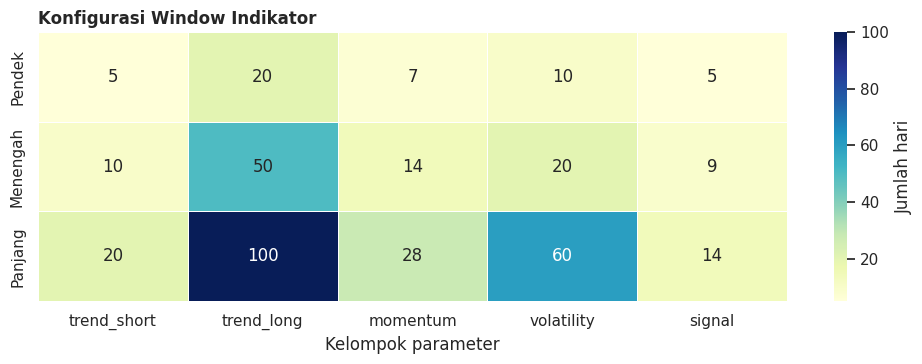

In [4]:
# 2. Parameter studi
TICKER = "^JKSE"
START_DATE = "2010-01-01"
END_DATE = None

# Jika memakai CSV Kaggle, isi path lengkap, misalnya:
# CSV_PATH = "/kaggle/input/ihsg-historical-data/ihsg.csv"
CSV_PATH = None

WINDOW_CONFIGS = {
    "Pendek": {
        "trend_short": 5,
        "trend_long": 20,
        "momentum": 7,
        "volatility": 10,
        "signal": 5,
    },
    "Menengah": {
        "trend_short": 10,
        "trend_long": 50,
        "momentum": 14,
        "volatility": 20,
        "signal": 9,
    },
    "Panjang": {
        "trend_short": 20,
        "trend_long": 100,
        "momentum": 28,
        "volatility": 60,
        "signal": 14,
    },
}

FEATURE_NAMES = [
    "SMA_Long",
    "EMA_Short",
    "WMA_Short",
    "RSI",
    "ROC",
    "Stochastic_K",
    "Stochastic_D",
    "MACD",
    "MACD_Signal",
    "CCI",
    "Williams_R",
    "ATR",
    "Bollinger_Width",
    "Volatility_Annualized",
    "MFI",
]

assert len(FEATURE_NAMES) == 15
window_table = pd.DataFrame(WINDOW_CONFIGS).T
window_table.index.name = "Konfigurasi"
print("OUTPUT TAHAP D: tiga konfigurasi window")
display(window_table)

fig, ax = plt.subplots(figsize=(10, 3.8))
sns.heatmap(
    window_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.7,
    cbar_kws={"label": "Jumlah hari"},
    ax=ax,
)
ax.set_title("Konfigurasi Window Indikator", loc="left", fontweight="bold")
ax.set_xlabel("Kelompok parameter")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## C. Data Dictionary

Setiap fitur memiliki definisi, input, parameter window, interpretasi, dan risiko redundansi. Parameter seperti `trend_long` atau `momentum` mengambil nilai dari konfigurasi yang sedang diuji.

In [5]:
# 3. Data Dictionary lengkap
DATA_DICTIONARY_RECORDS = [
    {
        "No": 1,
        "Fitur": "SMA_Long",
        "Kategori": "Tren",
        "Input": "Close",
        "Formula_ringkas": "mean(Close, trend_long)",
        "Parameter": "trend_long",
        "Satuan": "poin indeks",
        "Interpretasi": "Rata-rata arah harga jangka lebih panjang.",
        "Risiko_redundansi": "Tinggi dengan EMA, WMA, dan level Close.",
    },
    {
        "No": 2,
        "Fitur": "EMA_Short",
        "Kategori": "Tren",
        "Input": "Close",
        "Formula_ringkas": "EWMA(Close, trend_short)",
        "Parameter": "trend_short",
        "Satuan": "poin indeks",
        "Interpretasi": "Tren yang lebih responsif terhadap harga terbaru.",
        "Risiko_redundansi": "Tinggi dengan SMA dan WMA.",
    },
    {
        "No": 3,
        "Fitur": "WMA_Short",
        "Kategori": "Tren",
        "Input": "Close",
        "Formula_ringkas": "weighted_mean(Close, bobot 1..n)",
        "Parameter": "trend_short",
        "Satuan": "poin indeks",
        "Interpretasi": "Tren dengan bobot linear lebih besar pada data terbaru.",
        "Risiko_redundansi": "Tinggi dengan EMA_Short.",
    },
    {
        "No": 4,
        "Fitur": "RSI",
        "Kategori": "Momentum",
        "Input": "Close",
        "Formula_ringkas": "100 - 100/(1 + avg_gain/avg_loss)",
        "Parameter": "momentum",
        "Satuan": "indeks 0-100",
        "Interpretasi": "Kekuatan kenaikan dibandingkan penurunan.",
        "Risiko_redundansi": "Sedang dengan Stochastic dan Williams %R.",
    },
    {
        "No": 5,
        "Fitur": "ROC",
        "Kategori": "Momentum",
        "Input": "Close",
        "Formula_ringkas": "100 × (Close_t/Close_t-n - 1)",
        "Parameter": "momentum",
        "Satuan": "persen",
        "Interpretasi": "Laju perubahan harga selama n hari.",
        "Risiko_redundansi": "Sedang dengan return dan momentum oscillator.",
    },
    {
        "No": 6,
        "Fitur": "Stochastic_K",
        "Kategori": "Momentum",
        "Input": "High, Low, Close",
        "Formula_ringkas": "100 × (Close-low_n)/(high_n-low_n)",
        "Parameter": "momentum",
        "Satuan": "indeks 0-100",
        "Interpretasi": "Posisi penutupan dalam rentang harga n hari.",
        "Risiko_redundansi": "Tinggi dengan Williams_R.",
    },
    {
        "No": 7,
        "Fitur": "Stochastic_D",
        "Kategori": "Momentum",
        "Input": "Stochastic_K",
        "Formula_ringkas": "mean(Stochastic_K, signal)",
        "Parameter": "momentum + signal",
        "Satuan": "indeks 0-100",
        "Interpretasi": "Sinyal yang menghaluskan Stochastic_K.",
        "Risiko_redundansi": "Tinggi dengan Stochastic_K.",
    },
    {
        "No": 8,
        "Fitur": "MACD",
        "Kategori": "Tren-momentum",
        "Input": "Close",
        "Formula_ringkas": "EMA_short - EMA_long",
        "Parameter": "trend_short, trend_long",
        "Satuan": "poin indeks",
        "Interpretasi": "Selisih tren cepat dan lambat.",
        "Risiko_redundansi": "Tinggi dengan MACD_Signal dan moving average.",
    },
    {
        "No": 9,
        "Fitur": "MACD_Signal",
        "Kategori": "Tren-momentum",
        "Input": "MACD",
        "Formula_ringkas": "EWMA(MACD, signal)",
        "Parameter": "signal",
        "Satuan": "poin indeks",
        "Interpretasi": "Garis penghalus untuk membaca perubahan MACD.",
        "Risiko_redundansi": "Tinggi dengan MACD.",
    },
    {
        "No": 10,
        "Fitur": "CCI",
        "Kategori": "Momentum",
        "Input": "High, Low, Close",
        "Formula_ringkas": "(TP-SMA(TP))/(0.015 × mean_deviation)",
        "Parameter": "momentum",
        "Satuan": "indeks",
        "Interpretasi": "Deviasi typical price dari rata-ratanya.",
        "Risiko_redundansi": "Sedang dengan RSI dan Stochastic.",
    },
    {
        "No": 11,
        "Fitur": "Williams_R",
        "Kategori": "Momentum",
        "Input": "High, Low, Close",
        "Formula_ringkas": "-100 × (high_n-Close)/(high_n-low_n)",
        "Parameter": "momentum",
        "Satuan": "indeks -100 sampai 0",
        "Interpretasi": "Posisi penutupan terhadap rentang tertinggi-terendah.",
        "Risiko_redundansi": "Sangat tinggi dengan Stochastic_K.",
    },
    {
        "No": 12,
        "Fitur": "ATR",
        "Kategori": "Volatilitas",
        "Input": "High, Low, Close",
        "Formula_ringkas": "Wilder_mean(True Range, volatility)",
        "Parameter": "volatility",
        "Satuan": "poin indeks",
        "Interpretasi": "Rentang pergerakan aktual, termasuk gap.",
        "Risiko_redundansi": "Sedang dengan volatilitas dan Bollinger Width.",
    },
    {
        "No": 13,
        "Fitur": "Bollinger_Width",
        "Kategori": "Volatilitas",
        "Input": "Close",
        "Formula_ringkas": "(upper_band-lower_band)/middle_band",
        "Parameter": "volatility, k=2",
        "Satuan": "rasio",
        "Interpretasi": "Lebar relatif pita volatilitas.",
        "Risiko_redundansi": "Sedang dengan Volatility_Annualized.",
    },
    {
        "No": 14,
        "Fitur": "Volatility_Annualized",
        "Kategori": "Volatilitas",
        "Input": "Close",
        "Formula_ringkas": "std(log_return, volatility) × sqrt(252)",
        "Parameter": "volatility",
        "Satuan": "rasio tahunan",
        "Interpretasi": "Dispersi return yang disetarakan ke satu tahun.",
        "Risiko_redundansi": "Sedang dengan ATR dan Bollinger Width.",
    },
    {
        "No": 15,
        "Fitur": "MFI",
        "Kategori": "Arus dana",
        "Input": "High, Low, Close, Volume",
        "Formula_ringkas": "100 - 100/(1 + positive_flow/negative_flow)",
        "Parameter": "momentum",
        "Satuan": "indeks 0-100",
        "Interpretasi": "Tekanan beli-jual berbobot volume.",
        "Risiko_redundansi": "Sedang dengan RSI jika volume kurang informatif.",
    },
]

data_dictionary = pd.DataFrame(DATA_DICTIONARY_RECORDS)
assert data_dictionary["Fitur"].tolist() == FEATURE_NAMES
data_dictionary.insert(3, "Tipe_Data", "float64")
data_dictionary.insert(4, "Sumber_Data", "OHLCV harian IHSG")
expected_ranges = {
    "SMA_Long": "lebih dari 0",
    "EMA_Short": "lebih dari 0",
    "WMA_Short": "lebih dari 0",
    "RSI": "0 sampai 100",
    "ROC": "tidak dibatasi",
    "Stochastic_K": "0 sampai 100",
    "Stochastic_D": "0 sampai 100",
    "MACD": "tidak dibatasi",
    "MACD_Signal": "tidak dibatasi",
    "CCI": "tidak dibatasi",
    "Williams_R": "-100 sampai 0",
    "ATR": "0 atau lebih",
    "Bollinger_Width": "0 atau lebih",
    "Volatility_Annualized": "0 atau lebih",
    "MFI": "0 sampai 100",
}
data_dictionary["Rentang_Harapan"] = data_dictionary["Fitur"].map(
    expected_ranges
)
data_dictionary["Penanganan_NaN"] = (
    "Biarkan selama warm-up; hapus complete-case sebelum pemodelan"
)
print("OUTPUT TAHAP E: Data Dictionary 15 fitur")
display(data_dictionary)

dictionary_summary = (
    data_dictionary.groupby("Kategori", as_index=False)
    .agg(Jumlah_Fitur=("Fitur", "count"))
    .sort_values("Jumlah_Fitur", ascending=False)
)
display(dictionary_summary)

OUTPUT TAHAP E: Data Dictionary 15 fitur


,No,Fitur,Kategori,Tipe_Data,Sumber_Data,Input,Formula_ringkas,Parameter,Satuan,Interpretasi,Risiko_redundansi,Rentang_Harapan,Penanganan_NaN
0,1,SMA_Long,Tren,float64,OHLCV harian IHSG,Close,"mean(Close, trend_long)",trend_long,poin indeks,Rata-rata arah harga jangka lebih panjang.,"Tinggi dengan EMA, WMA, dan level Close.",lebih dari 0,Biarkan selama warm-up; hapus complete-case sebelum pemodelan
1,2,EMA_Short,Tren,float64,OHLCV harian IHSG,Close,"EWMA(Close, trend_short)",trend_short,poin indeks,Tren yang lebih responsif terhadap harga terbaru.,Tinggi dengan SMA dan WMA.,lebih dari 0,Biarkan selama warm-up; hapus complete-case sebelum pemodelan
2,3,WMA_Short,Tren,float64,OHLCV harian IHSG,Close,"weighted_mean(Close, bobot 1..n)",trend_short,poin indeks,Tren dengan bobot linear lebih besar pada data terbaru.,Tinggi dengan EMA_Short.,lebih dari 0,Biarkan selama warm-up; hapus complete-case sebelum pemodelan
3,4,RSI,Momentum,float64,OHLCV harian IHSG,Close,100 - 100/(1 + avg_gain/avg_loss),momentum,indeks 0-100,Kekuatan kenaikan dibandingkan penurunan.,Sedang dengan Stochastic dan Williams %R.,0 sampai 100,Biarkan selama warm-up; hapus complete-case sebelum pemodelan
4,5,ROC,Momentum,float64,OHLCV harian IHSG,Close,100 × (Close_t/Close_t-n - 1),momentum,persen,Laju perubahan harga selama n hari.,Sedang dengan return dan momentum oscillator.,tidak dibatasi,Biarkan selama warm-up; hapus complete-case sebelum pemodelan
5,6,Stochastic_K,Momentum,float64,OHLCV harian IHSG,"High, Low, Close",100 × (Close-low_n)/(high_n-low_n),momentum,indeks 0-100,Posisi penutupan dalam rentang harga n hari.,Tinggi dengan Williams_R.,0 sampai 100,Biarkan selama warm-up; hapus complete-case sebelum pemodelan
6,7,Stochastic_D,Momentum,float64,OHLCV harian IHSG,Stochastic_K,"mean(Stochastic_K, signal)",momentum + signal,indeks 0-100,Sinyal yang menghaluskan Stochastic_K.,Tinggi dengan Stochastic_K.,0 sampai 100,Biarkan selama warm-up; hapus complete-case sebelum pemodelan
7,8,MACD,Tren-momentum,float64,OHLCV harian IHSG,Close,EMA_short - EMA_long,"trend_short, trend_long",poin indeks,Selisih tren cepat dan lambat.,Tinggi dengan MACD_Signal dan moving average.,tidak dibatasi,Biarkan selama warm-up; hapus complete-case sebelum pemodelan
8,9,MACD_Signal,Tren-momentum,float64,OHLCV harian IHSG,MACD,"EWMA(MACD, signal)",signal,poin indeks,Garis penghalus untuk membaca perubahan MACD.,Tinggi dengan MACD.,tidak dibatasi,Biarkan selama warm-up; hapus complete-case sebelum pemodelan
9,10,CCI,Momentum,float64,OHLCV harian IHSG,"High, Low, Close",(TP-SMA(TP))/(0.015 × mean_deviation),momentum,indeks,Deviasi typical price dari rata-ratanya.,Sedang dengan RSI dan Stochastic.,tidak dibatasi,Biarkan selama warm-up; hapus complete-case sebelum pemodelan


,Kategori,Jumlah_Fitur
1,Momentum,6
4,Volatilitas,3
2,Tren,3
3,Tren-momentum,2
0,Arus dana,1


## D. Fungsi Pipeline Fitur

Semua operasi menggunakan rolling window ke belakang. Tidak ada `center=True`, backfill, atau normalisasi global. Model memakai pipeline `StandardScaler → LogisticRegression`, sehingga scaler selalu dipelajari dari fold train.

In [6]:
# 4. Fungsi rekayasa fitur kausal
def safe_divide(numerator, denominator):
    denominator = denominator.replace(0, np.nan)
    return numerator / denominator


def weighted_moving_average(series, window):
    weights = np.arange(1, window + 1, dtype=float)
    return series.rolling(window=window, min_periods=window).apply(
        lambda values: np.dot(values, weights) / weights.sum(),
        raw=True,
    )


def rolling_mean_deviation(values):
    values = np.asarray(values, dtype=float)
    return np.mean(np.abs(values - values.mean()))


def build_technical_features(ohlcv, config):
    required = {"Open", "High", "Low", "Close", "Volume"}
    missing = required.difference(ohlcv.columns)
    if missing:
        raise ValueError(f"Kolom OHLCV tidak lengkap: {sorted(missing)}")

    short = int(config["trend_short"])
    long = int(config["trend_long"])
    momentum = int(config["momentum"])
    volatility = int(config["volatility"])
    signal = int(config["signal"])

    if not (2 <= short < long):
        raise ValueError("Syarat window: 2 <= trend_short < trend_long.")
    if min(momentum, volatility, signal) < 2:
        raise ValueError("Seluruh window harus minimal 2.")

    high = ohlcv["High"].astype(float)
    low = ohlcv["Low"].astype(float)
    close = ohlcv["Close"].astype(float)
    volume = ohlcv["Volume"].astype(float)

    features = pd.DataFrame(index=ohlcv.index)

    # Tren
    features["SMA_Long"] = close.rolling(long, min_periods=long).mean()
    features["EMA_Short"] = close.ewm(
        span=short, adjust=False, min_periods=short
    ).mean()
    features["WMA_Short"] = weighted_moving_average(close, short)

    # RSI dengan penghalusan Wilder
    delta = close.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(
        alpha=1 / momentum, adjust=False, min_periods=momentum
    ).mean()
    avg_loss = loss.ewm(
        alpha=1 / momentum, adjust=False, min_periods=momentum
    ).mean()
    rs = safe_divide(avg_gain, avg_loss)
    rsi = 100 - (100 / (1 + rs))
    rsi = rsi.mask((avg_loss == 0) & (avg_gain > 0), 100.0)
    rsi = rsi.mask((avg_loss == 0) & (avg_gain == 0), 50.0)
    features["RSI"] = rsi

    # Rate of Change
    features["ROC"] = close.pct_change(momentum) * 100

    # Stochastic oscillator
    rolling_low = low.rolling(momentum, min_periods=momentum).min()
    rolling_high = high.rolling(momentum, min_periods=momentum).max()
    price_range = rolling_high - rolling_low
    stochastic_k = safe_divide(
        close - rolling_low, price_range
    ) * 100
    stochastic_k = stochastic_k.mask(price_range == 0, 50.0)
    features["Stochastic_K"] = stochastic_k
    features["Stochastic_D"] = features["Stochastic_K"].rolling(
        signal, min_periods=signal
    ).mean()

    # MACD
    ema_fast = close.ewm(
        span=short, adjust=False, min_periods=short
    ).mean()
    ema_slow = close.ewm(
        span=long, adjust=False, min_periods=long
    ).mean()
    features["MACD"] = ema_fast - ema_slow
    features["MACD_Signal"] = features["MACD"].ewm(
        span=signal, adjust=False, min_periods=signal
    ).mean()

    # Commodity Channel Index
    typical_price = (high + low + close) / 3
    tp_mean = typical_price.rolling(
        momentum, min_periods=momentum
    ).mean()
    mean_dev = typical_price.rolling(
        momentum, min_periods=momentum
    ).apply(rolling_mean_deviation, raw=True)
    cci = safe_divide(
        typical_price - tp_mean, 0.015 * mean_dev
    )
    features["CCI"] = cci.mask(mean_dev == 0, 0.0)

    # Williams %R
    williams_r = -100 * safe_divide(
        rolling_high - close, price_range
    )
    features["Williams_R"] = williams_r.mask(
        price_range == 0, -50.0
    )

    # Average True Range
    previous_close = close.shift(1)
    true_range = pd.concat(
        [
            high - low,
            (high - previous_close).abs(),
            (low - previous_close).abs(),
        ],
        axis=1,
    ).max(axis=1)
    features["ATR"] = true_range.ewm(
        alpha=1 / volatility,
        adjust=False,
        min_periods=volatility,
    ).mean()

    # Bollinger Bandwidth dan volatilitas log return
    bb_middle = close.rolling(
        volatility, min_periods=volatility
    ).mean()
    bb_std = close.rolling(
        volatility, min_periods=volatility
    ).std(ddof=1)
    features["Bollinger_Width"] = safe_divide(4 * bb_std, bb_middle)

    log_return = np.log(close).diff()
    features["Volatility_Annualized"] = (
        log_return.rolling(
            volatility, min_periods=volatility
        ).std(ddof=1)
        * np.sqrt(TRADING_DAYS)
    )

    # Money Flow Index
    raw_money_flow = typical_price * volume
    direction = typical_price.diff()
    positive_flow = raw_money_flow.where(direction > 0, 0.0)
    negative_flow = raw_money_flow.where(direction < 0, 0.0)
    positive_sum = positive_flow.rolling(
        momentum, min_periods=momentum
    ).sum()
    negative_sum = negative_flow.rolling(
        momentum, min_periods=momentum
    ).sum()
    money_ratio = safe_divide(positive_sum, negative_sum)
    mfi = 100 - (100 / (1 + money_ratio))
    mfi = mfi.mask(
        (negative_sum == 0) & (positive_sum > 0), 100.0
    )
    mfi = mfi.mask(
        (negative_sum == 0) & (positive_sum == 0), 50.0
    )
    features["MFI"] = mfi

    features = features.replace([np.inf, -np.inf], np.nan)
    features = features[FEATURE_NAMES]
    return features


def add_prediction_target(features, close):
    result = features.copy()
    next_log_return = np.log(close.shift(-1) / close)
    result["Target_Log_Return_1D"] = next_log_return
    result["Target_Up_1D"] = np.where(
        next_log_return.notna(),
        (next_log_return > 0).astype(int),
        np.nan,
    )
    return result

In [7]:
# 5. Unit test untuk bug umum dan kausalitas fitur
def run_feature_unit_tests():
    n = 260
    index = pd.bdate_range("2020-01-01", periods=n)
    rng = np.random.default_rng(RANDOM_STATE)
    close = 5000 * np.exp(np.cumsum(rng.normal(0.0002, 0.01, n)))
    open_ = close * (1 + rng.normal(0, 0.002, n))
    high = np.maximum(open_, close) * (1 + rng.uniform(0.001, 0.01, n))
    low = np.minimum(open_, close) * (1 - rng.uniform(0.001, 0.01, n))
    volume = rng.integers(1_000_000, 10_000_000, n)

    synthetic = pd.DataFrame(
        {
            "Open": open_,
            "High": high,
            "Low": low,
            "Close": close,
            "Volume": volume,
        },
        index=index,
    )

    config = WINDOW_CONFIGS["Menengah"]
    original = build_technical_features(synthetic, config)
    assert original.shape[1] == 15
    assert original.columns.tolist() == FEATURE_NAMES
    assert not np.isinf(original.to_numpy(dtype=float)).any()

    # Ubah masa depan secara ekstrem. Fitur masa lalu tidak boleh berubah.
    altered = synthetic.copy()
    altered.loc[index[-1], ["Open", "High", "Low", "Close"]] *= 5
    changed = build_technical_features(altered, config)
    pd.testing.assert_frame_equal(
        original.iloc[:-1],
        changed.iloc[:-1],
        check_exact=False,
        rtol=1e-12,
        atol=1e-12,
    )

    # Target terakhir wajib NaN karena return t+1 belum tersedia.
    labeled = add_prediction_target(original, synthetic["Close"])
    assert pd.isna(labeled["Target_Log_Return_1D"].iloc[-1])
    assert pd.isna(labeled["Target_Up_1D"].iloc[-1])

    # Seri datar menguji pembagian nol pada oscillator.
    flat = pd.DataFrame(
        {
            "Open": np.full(n, 5000.0),
            "High": np.full(n, 5000.0),
            "Low": np.full(n, 5000.0),
            "Close": np.full(n, 5000.0),
            "Volume": np.full(n, 1_000_000.0),
        },
        index=index,
    )
    flat_features = build_technical_features(flat, config)
    last = flat_features.iloc[-1]
    assert last["RSI"] == 50.0
    assert last["Stochastic_K"] == 50.0
    assert last["Williams_R"] == -50.0
    assert last["CCI"] == 0.0
    assert last["MFI"] == 50.0

    return (
        "LULUS: 15 fitur, batas pembagian nol, target, infinity, "
        "dan kausalitas telah diperiksa."
    )


unit_test_message = run_feature_unit_tests()
unit_test_results = pd.DataFrame(
    {
        "Pemeriksaan": [
            "Jumlah dan urutan fitur",
            "Nilai infinity",
            "Kausalitas",
            "Target t+1",
            "Pembagian nol oscillator",
        ],
        "Status": ["LULUS"] * 5,
        "Makna": [
            "Tepat 15 fitur sesuai Data Dictionary",
            "Tidak ada nilai positif atau negatif tak hingga",
            "Perubahan masa depan tidak mengubah fitur masa lalu",
            "Target terakhir kosong karena masa depan belum tersedia",
            "Seri datar menghasilkan nilai netral yang terdefinisi",
        ],
    }
)
print("OUTPUT TAHAP F:", unit_test_message)
display(unit_test_results)

OUTPUT TAHAP F: LULUS: 15 fitur, batas pembagian nol, target, infinity, dan kausalitas telah diperiksa.


,Pemeriksaan,Status,Makna
0,Jumlah dan urutan fitur,LULUS,Tepat 15 fitur sesuai Data Dictionary
1,Nilai infinity,LULUS,Tidak ada nilai positif atau negatif tak hingga
2,Kausalitas,LULUS,Perubahan masa depan tidak mengubah fitur masa lalu
3,Target t+1,LULUS,Target terakhir kosong karena masa depan belum tersedia
4,Pembagian nol oscillator,LULUS,Seri datar menghasilkan nilai netral yang terdefinisi


## E. Akuisisi dan Pemeriksaan Data IHSG

Notebook memprioritaskan CSV yang Anda tetapkan melalui `CSV_PATH`. Jika kosong, notebook mencari berkas dengan nama yang memuat `ihsg`, `jkse`, atau `composite` di `/kaggle/input`. Jika tetap tidak ditemukan, notebook mengunduh `^JKSE`.

Format CSV minimal: `Date, Open, High, Low, Close, Volume`. Kolom `Adj Close` boleh tersedia, tetapi tidak wajib.

In [8]:
# 6. Fungsi akuisisi, normalisasi, dan validasi OHLCV
def flatten_columns(frame):
    result = frame.copy()
    if isinstance(result.columns, pd.MultiIndex):
        result.columns = [
            col[0] if isinstance(col, tuple) else col
            for col in result.columns
        ]
    return result


def standardize_ohlcv(frame):
    data = flatten_columns(frame)
    data.columns = [
        str(col).strip().replace("_", " ").title()
        for col in data.columns
    ]

    aliases = {
        "Adjclose": "Adj Close",
        "Adjusted Close": "Adj Close",
        "Tanggal": "Date",
        "Harga": "Close",
        "Vol": "Volume",
    }
    data = data.rename(columns=aliases)

    if not isinstance(data.index, pd.DatetimeIndex):
        date_candidates = [
            col for col in data.columns
            if col.lower() in {"date", "datetime", "timestamp"}
        ]
        if not date_candidates:
            raise ValueError(
                "Kolom tanggal tidak ditemukan. Gunakan nama Date atau Datetime."
            )
        date_col = date_candidates[0]
        data[date_col] = pd.to_datetime(data[date_col], errors="coerce")
        data = data.set_index(date_col)

    data.index = pd.to_datetime(data.index, errors="coerce")
    if getattr(data.index, "tz", None) is not None:
        data.index = data.index.tz_localize(None)

    required = ["Open", "High", "Low", "Close", "Volume"]
    missing = [col for col in required if col not in data.columns]
    if missing:
        raise ValueError(f"Kolom wajib tidak ditemukan: {missing}")

    data = data[required].copy()
    for col in required:
        if data[col].dtype == object:
            cleaned = (
                data[col]
                .astype(str)
                .str.replace(",", "", regex=False)
                .str.replace("Rp", "", regex=False)
                .str.strip()
            )
            data[col] = pd.to_numeric(cleaned, errors="coerce")
        else:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    data = (
        data.loc[data.index.notna()]
        .sort_index()
        .loc[lambda x: ~x.index.duplicated(keep="last")]
    )
    data = data.dropna(subset=required)
    return data


def find_candidate_csv():
    patterns = [
        "/kaggle/input/**/*ihsg*.csv",
        "/kaggle/input/**/*jkse*.csv",
        "/kaggle/input/**/*composite*.csv",
    ]
    candidates = []
    for pattern in patterns:
        candidates.extend(glob.glob(pattern, recursive=True))
    return sorted(set(candidates))


def load_ihsg_data(csv_path=None):
    if csv_path:
        path = Path(csv_path)
        if not path.exists():
            raise FileNotFoundError(f"CSV_PATH tidak ditemukan: {path}")
        print(f"Sumber data: CSV yang ditentukan, {path.name}")
        return standardize_ohlcv(pd.read_csv(path))

    candidates = find_candidate_csv()
    if candidates:
        selected = candidates[0]
        print(f"Sumber data: Kaggle Input, {Path(selected).name}")
        return standardize_ohlcv(pd.read_csv(selected))

    try:
        import yfinance as yf
    except ImportError:
        print("Memasang yfinance karena CSV IHSG tidak ditemukan...")
        import subprocess
        subprocess.check_call(
            [sys.executable, "-m", "pip", "install", "-q", "yfinance"]
        )
        import yfinance as yf

    print(f"Sumber data: Yahoo Finance, ticker {TICKER}")
    downloaded = yf.download(
        TICKER,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=False,
        progress=False,
        threads=False,
    )
    if downloaded.empty:
        raise RuntimeError(
            "Unduhan ^JKSE kosong. Aktifkan Internet di Kaggle Settings "
            "atau unggah CSV dan isi variabel CSV_PATH."
        )
    return standardize_ohlcv(downloaded)


def validate_market_data(data):
    errors = []
    if len(data) < 500:
        errors.append("Data kurang dari 500 observasi.")
    if not data.index.is_monotonic_increasing:
        errors.append("Tanggal belum berurutan.")
    if data.index.has_duplicates:
        errors.append("Tanggal masih mengandung duplikasi.")
    if (data[["Open", "High", "Low", "Close"]] <= 0).any().any():
        errors.append("Harga nol atau negatif ditemukan.")
    if (data["Volume"] < 0).any():
        errors.append("Volume negatif ditemukan.")
    if (data["High"] < data[["Open", "Low", "Close"]].max(axis=1)).any():
        errors.append("Ada High yang lebih rendah dari Open/Low/Close.")
    if (data["Low"] > data[["Open", "High", "Close"]].min(axis=1)).any():
        errors.append("Ada Low yang lebih tinggi dari Open/High/Close.")
    if errors:
        raise ValueError("Validasi data gagal:\n- " + "\n- ".join(errors))
    return True

In [9]:
# 7. Muat data dan tampilkan ringkasan aman
raw_data = load_ihsg_data(CSV_PATH)
validate_market_data(raw_data)

quality_summary = pd.DataFrame(
    {
        "Ukuran": [
            "Jumlah observasi",
            "Tanggal awal",
            "Tanggal akhir",
            "Nilai hilang",
            "Tanggal duplikat",
            "Harga nonpositif",
            "Volume negatif",
        ],
        "Nilai": [
            f"{len(raw_data):,}",
            str(raw_data.index.min().date()),
            str(raw_data.index.max().date()),
            int(raw_data.isna().sum().sum()),
            int(raw_data.index.duplicated().sum()),
            int((raw_data[["Open", "High", "Low", "Close"]] <= 0).sum().sum()),
            int((raw_data["Volume"] < 0).sum()),
        ],
        "Status": ["INFO", "INFO", "INFO", "LULUS", "LULUS", "LULUS", "LULUS"],
    }
)
print("OUTPUT TAHAP G: ringkasan dan kualitas data IHSG")
display(quality_summary)
display(raw_data.head())

Sumber data: Yahoo Finance, ticker ^JKSE
OUTPUT TAHAP G: ringkasan dan kualitas data IHSG


,Ukuran,Nilai,Status
0,Jumlah observasi,"4,019",INFO
1,Tanggal awal,2010-01-04,INFO
2,Tanggal akhir,2026-07-30,INFO
3,Nilai hilang,0,LULUS
4,Tanggal duplikat,0,LULUS
5,Harga nonpositif,0,LULUS
6,Volume negatif,0,LULUS


,Open,High,Low,Close,Volume
Date,,,,,
2010-01-04,2533.947998,2576.055908,2532.895996,2575.413086,18339300
2010-01-05,2575.616943,2606.069092,2575.616943,2605.277100,57043800
2010-01-06,2605.480957,2622.115967,2587.709961,2603.297119,51569100
2010-01-07,2603.500977,2611.603027,2570.272949,2586.895020,45510800
2010-01-08,2586.792969,2614.535889,2583.846924,2614.370117,73723500


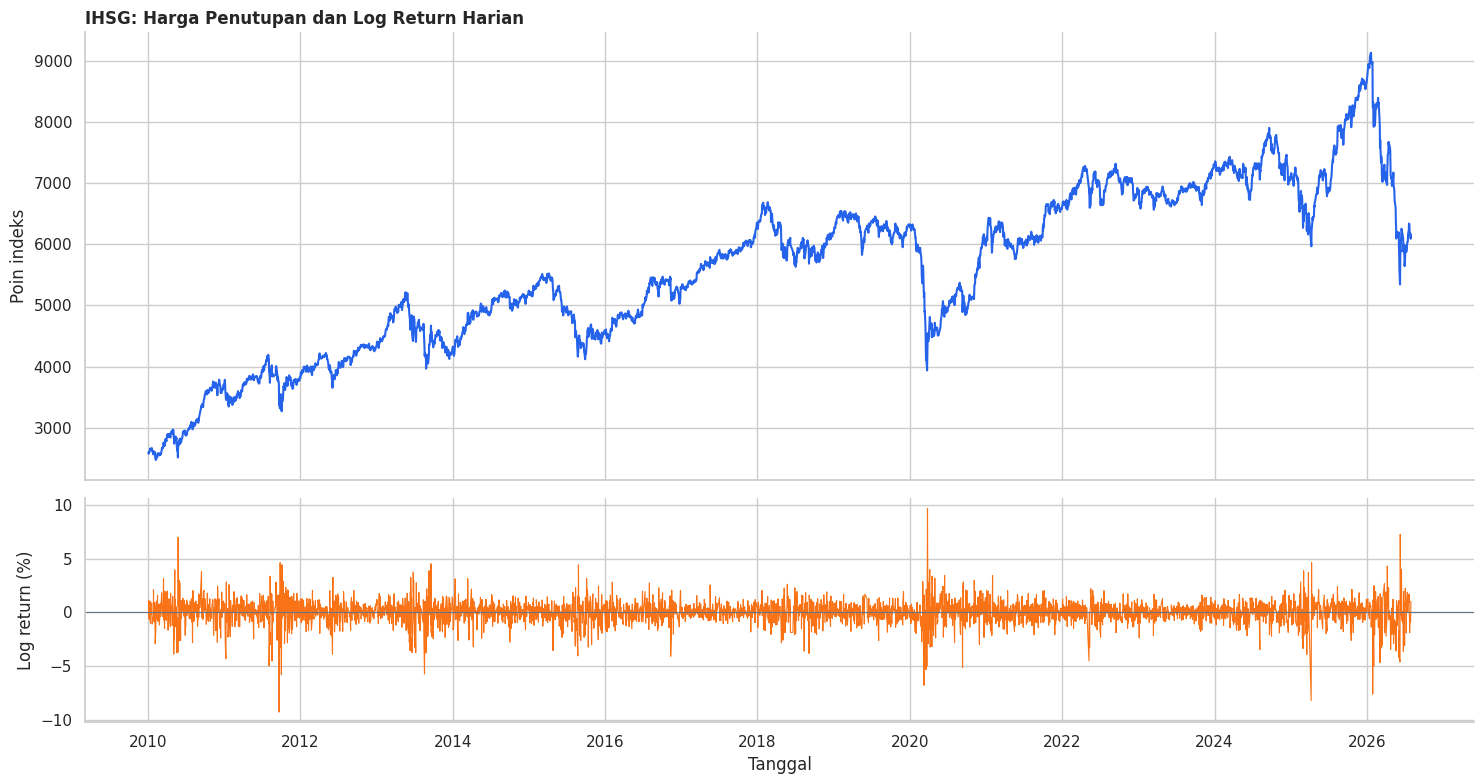

OUTPUT TAHAP H: statistik deskriptif return


,count,mean,std,min,1%,5%,50%,95%,99%,max
Log_Return,4018.0,0.000217,0.010941,-0.092997,-0.03362,-0.017121,0.000787,0.015894,0.028091,0.097042


In [10]:
# 8. Eksplorasi awal data IHSG
eda_frame = raw_data.copy()
eda_frame["Log_Return"] = np.log(eda_frame["Close"]).diff()

fig, axes = plt.subplots(
    2, 1, figsize=(15, 8), sharex=True,
    gridspec_kw={"height_ratios": [2, 1]}
)
axes[0].plot(
    eda_frame.index, eda_frame["Close"],
    color="#2563EB", lw=1.5
)
axes[0].set_title(
    "IHSG: Harga Penutupan dan Log Return Harian",
    loc="left", fontweight="bold"
)
axes[0].set_ylabel("Poin indeks")

axes[1].plot(
    eda_frame.index, eda_frame["Log_Return"] * 100,
    color="#F97316", lw=0.8
)
axes[1].axhline(0, color="#64748B", lw=0.8)
axes[1].set_ylabel("Log return (%)")
axes[1].set_xlabel("Tanggal")
sns.despine()
plt.tight_layout()
plt.show()

return_summary = eda_frame["Log_Return"].describe(
    percentiles=[0.01, 0.05, 0.50, 0.95, 0.99]
).to_frame("Log_Return").T
print("OUTPUT TAHAP H: statistik deskriptif return")
display(return_summary.round(6))

In [11]:
# 9. Split kronologis dan penguncian data test
n_rows = len(raw_data)
train_stop = int(np.floor(n_rows * 0.70))
validation_stop = int(np.floor(n_rows * 0.85))

if train_stop < 300 or validation_stop <= train_stop:
    raise ValueError("Data tidak cukup untuk split dan validasi deret waktu.")

train_end_date = raw_data.index[train_stop - 1]
validation_end_date = raw_data.index[validation_stop - 1]

# development_raw memuat train + validation.
development_raw = raw_data.iloc[:validation_stop].copy()

# test_vault dibuat lalu tidak dipakai pada proses pemilihan konfigurasi.
test_vault = raw_data.iloc[validation_stop:].copy()
TEST_UNLOCKED = False

assert development_raw.index.max() < test_vault.index.min()
assert train_end_date < validation_end_date

split_summary = pd.DataFrame(
    {
        "Bagian": ["Train", "Validation", "Test Vault"],
        "Proporsi": ["70%", "15%", "15%"],
        "Status": [
            "Dipakai melatih dan cross-validation",
            "Dipakai memilih konfigurasi",
            "TERKUNCI, tidak dianalisis",
        ],
    }
)
split_summary["Jumlah_Baris"] = [
    train_stop,
    validation_stop - train_stop,
    n_rows - validation_stop,
]
split_summary["Tanggal_Awal"] = [
    raw_data.index[0].date(),
    raw_data.index[train_stop].date(),
    raw_data.index[validation_stop].date(),
]
split_summary["Tanggal_Akhir"] = [
    raw_data.index[train_stop - 1].date(),
    raw_data.index[validation_stop - 1].date(),
    raw_data.index[-1].date(),
]
print("OUTPUT TAHAP I: pembagian kronologis")
display(split_summary)
print("Data test terkunci:", not TEST_UNLOCKED)

OUTPUT TAHAP I: pembagian kronologis


,Bagian,Proporsi,Status,Jumlah_Baris,Tanggal_Awal,Tanggal_Akhir
0,Train,70%,Dipakai melatih dan cross-validation,2813,2010-01-04,2021-07-19
1,Validation,15%,Dipakai memilih konfigurasi,603,2021-07-21,2024-01-05
2,Test Vault,15%,"TERKUNCI, tidak dianalisis",603,2024-01-08,2026-07-30


Data test terkunci: True


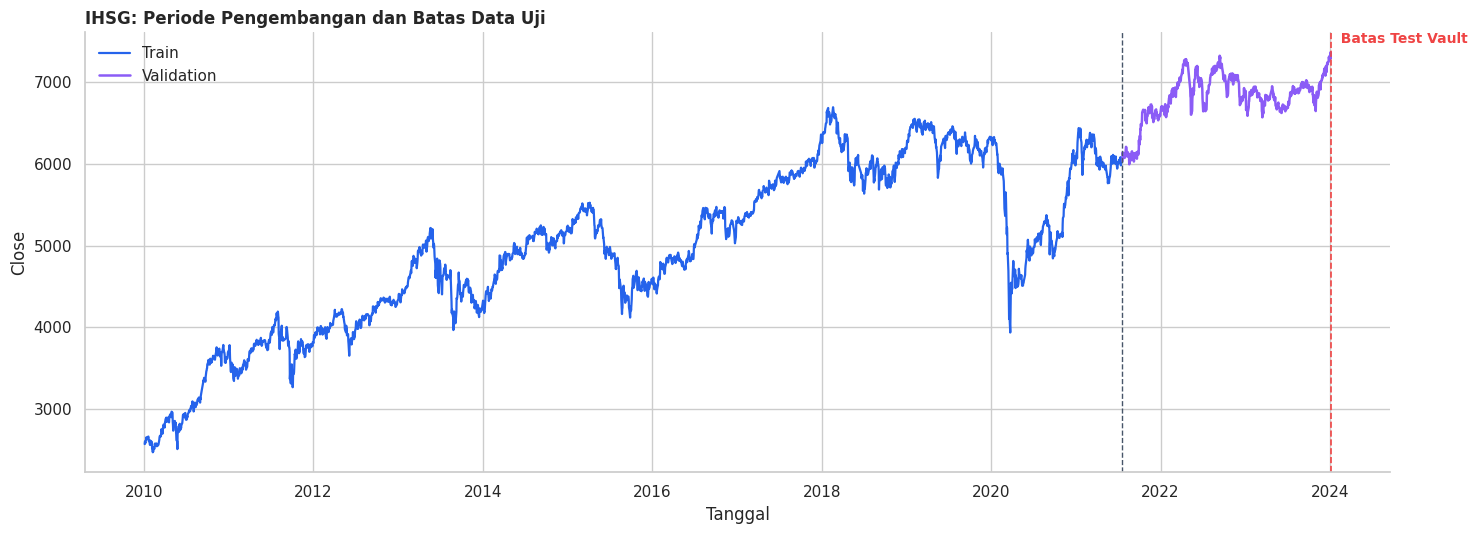

In [12]:
# 10. Visualisasi pembagian periode tanpa menampilkan isi test
fig, ax = plt.subplots(figsize=(15, 5.5))
train_close = development_raw.loc[:train_end_date, "Close"]
valid_close = development_raw.loc[
    (development_raw.index > train_end_date)
    & (development_raw.index <= validation_end_date),
    "Close",
]

ax.plot(train_close.index, train_close, color=COLORS["Train"], lw=1.6, label="Train")
ax.plot(valid_close.index, valid_close, color=COLORS["Validation"], lw=1.8, label="Validation")
ax.axvline(train_end_date, color="#475569", ls="--", lw=1)
ax.axvline(validation_end_date, color=COLORS["Test"], ls="--", lw=1.2)
ax.text(
    validation_end_date,
    ax.get_ylim()[1],
    "  Batas Test Vault",
    color=COLORS["Test"],
    va="top",
    fontsize=10,
    fontweight="bold",
)
ax.set_title("IHSG: Periode Pengembangan dan Batas Data Uji", loc="left", fontweight="bold")
ax.set_xlabel("Tanggal")
ax.set_ylabel("Close")
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## F. Analisis Warm-up

Warm-up adalah jumlah baris awal yang belum memiliki nilai indikator. Window yang lebih panjang memperbesar warm-up dan mengurangi sampel efektif. Tabel berikut membedakan perkiraan teoretis dan hasil aktual.

In [13]:
# 10. Fungsi tabel warm-up
def theoretical_warmup(config):
    short = config["trend_short"]
    long = config["trend_long"]
    momentum = config["momentum"]
    volatility = config["volatility"]
    signal = config["signal"]
    return {
        "SMA_Long": long - 1,
        "EMA_Short": short - 1,
        "WMA_Short": short - 1,
        "RSI": momentum,
        "ROC": momentum,
        "Stochastic_K": momentum - 1,
        "Stochastic_D": momentum + signal - 2,
        "MACD": long - 1,
        "MACD_Signal": long + signal - 2,
        "CCI": momentum - 1,
        "Williams_R": momentum - 1,
        "ATR": volatility - 1,
        "Bollinger_Width": volatility - 1,
        "Volatility_Annualized": volatility,
        "MFI": momentum - 1,
    }


def actual_warmup_table(features, config_name, config):
    theoretical = theoretical_warmup(config)
    records = []
    for feature in FEATURE_NAMES:
        first_valid = features[feature].first_valid_index()
        if first_valid is None:
            actual = np.nan
            first_date = pd.NaT
        else:
            actual = features.index.get_loc(first_valid)
            first_date = first_valid
        records.append(
            {
                "Konfigurasi": config_name,
                "Fitur": feature,
                "Warmup_Teoretis": theoretical[feature],
                "Warmup_Aktual": actual,
                "Tanggal_Pertama_Valid": first_date,
                "Selisih_Aktual_Teoretis": (
                    actual - theoretical[feature]
                    if pd.notna(actual)
                    else np.nan
                ),
            }
        )
    return pd.DataFrame(records)


feature_frames = {}
warmup_tables = []

for config_name, config in WINDOW_CONFIGS.items():
    frame = build_technical_features(development_raw, config)
    feature_frames[config_name] = add_prediction_target(
        frame, development_raw["Close"]
    )
    warmup_tables.append(
        actual_warmup_table(frame, config_name, config)
    )

warmup_analysis = pd.concat(warmup_tables, ignore_index=True)
common_train_start_date = max(
    labeled.dropna(subset=FEATURE_NAMES).index.min()
    for labeled in feature_frames.values()
)

warmup_summary = (
    warmup_analysis.groupby("Konfigurasi", as_index=False)
    .agg(
        Warmup_Maksimum=("Warmup_Aktual", "max"),
        Warmup_Rata_Rata=("Warmup_Aktual", "mean"),
        Fitur_Terlambat=(
            "Fitur",
            lambda s: ", ".join(
                warmup_analysis.loc[
                    s.index[
                        warmup_analysis.loc[s.index, "Warmup_Aktual"]
                        == warmup_analysis.loc[s.index, "Warmup_Aktual"].max()
                    ],
                    "Fitur",
                ].tolist()
            ),
        ),
    )
)
warmup_summary["Observasi_Development"] = len(development_raw)
warmup_summary["Persen_Hilang_Maks"] = (
    warmup_summary["Warmup_Maksimum"]
    / warmup_summary["Observasi_Development"]
    * 100
)

print("OUTPUT TAHAP K: analisis warm-up")
display(warmup_summary.round(2))
display(warmup_analysis.head(15))
print(
    "Awal sampel bersama untuk perbandingan adil:",
    common_train_start_date.date(),
)

OUTPUT TAHAP K: analisis warm-up


,Konfigurasi,Warmup_Maksimum,Warmup_Rata_Rata,Fitur_Terlambat,Observasi_Development,Persen_Hilang_Maks
0,Menengah,57,22.13,MACD_Signal,3416,1.67
1,Panjang,112,48.67,MACD_Signal,3416,3.28
2,Pendek,23,9.67,MACD_Signal,3416,0.67


,Konfigurasi,Fitur,Warmup_Teoretis,Warmup_Aktual,Tanggal_Pertama_Valid,Selisih_Aktual_Teoretis
0,Pendek,SMA_Long,19,19,2010-01-29,0
1,Pendek,EMA_Short,4,4,2010-01-08,0
2,Pendek,WMA_Short,4,4,2010-01-08,0
3,Pendek,RSI,7,7,2010-01-13,0
4,Pendek,ROC,7,7,2010-01-13,0
5,Pendek,Stochastic_K,6,6,2010-01-12,0
6,Pendek,Stochastic_D,10,10,2010-01-18,0
7,Pendek,MACD,19,19,2010-01-29,0
8,Pendek,MACD_Signal,23,23,2010-02-04,0
9,Pendek,CCI,6,6,2010-01-12,0


Awal sampel bersama untuk perbandingan adil: 2010-06-16


OUTPUT TAHAP J: kelengkapan hasil feature engineering


,Konfigurasi,Baris_Total,Baris_15_Fitur_Lengkap,Nilai_Fitur_Hilang,Tanggal_Pertama_Lengkap
0,Pendek,3416,3393,145,2010-02-04
1,Menengah,3416,3359,332,2010-03-26
2,Panjang,3416,3304,730,2010-06-16


,SMA_Long,RSI,MACD,ATR,Volatility_Annualized,MFI,Target_Up_1D
Date,,,,,,,
2023-12-21,6955.1966,62.6565,144.6488,72.8802,0.0963,53.4408,1.0
2023-12-22,6961.4114,64.5532,150.1372,71.1826,0.0966,50.6647,1.0
2023-12-27,6968.4039,65.1273,154.5786,70.4238,0.0965,57.9610,1.0
2023-12-28,6975.6894,68.8753,165.2347,70.0171,0.0988,55.8587,0.0
2023-12-29,6982.5872,64.8497,167.9996,69.0212,0.1008,58.0156,1.0
2024-01-02,6992.1304,68.1270,176.2182,69.4712,0.1013,55.6994,0.0
2024-01-03,7000.7289,62.6187,175.0769,68.3834,0.1037,63.4255,1.0
2024-01-04,7013.0849,67.7152,184.4355,69.5714,0.1086,61.8891,0.0


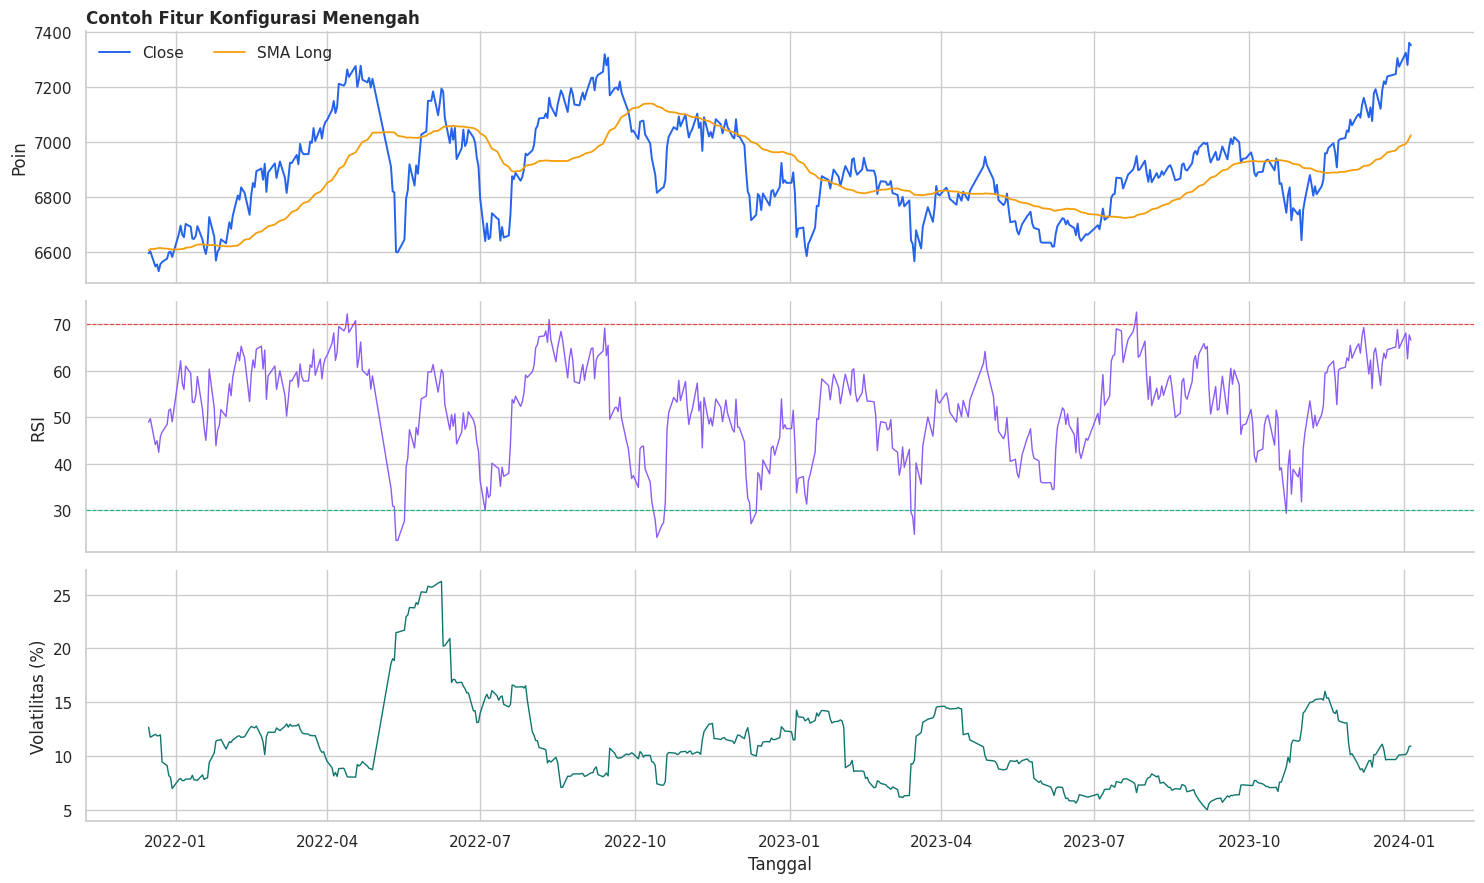

In [14]:
# 12. Preview hasil pipeline fitur sebelum pemodelan
completeness_records = []
for config_name, labeled in feature_frames.items():
    valid_matrix = labeled[FEATURE_NAMES].notna()
    completeness_records.append(
        {
            "Konfigurasi": config_name,
            "Baris_Total": len(labeled),
            "Baris_15_Fitur_Lengkap": int(valid_matrix.all(axis=1).sum()),
            "Nilai_Fitur_Hilang": int((~valid_matrix).sum().sum()),
            "Tanggal_Pertama_Lengkap": valid_matrix.all(axis=1)
            .loc[lambda s: s]
            .index.min(),
        }
    )
feature_completeness = pd.DataFrame(completeness_records)
print("OUTPUT TAHAP J: kelengkapan hasil feature engineering")
display(feature_completeness)

preview_columns = [
    "SMA_Long", "RSI", "MACD", "ATR",
    "Volatility_Annualized", "MFI", "Target_Up_1D"
]
display(
    feature_frames["Menengah"][preview_columns]
    .dropna()
    .tail(8)
    .round(4)
)

preview = feature_frames["Menengah"].dropna(subset=FEATURE_NAMES).tail(500)
fig, axes = plt.subplots(3, 1, figsize=(15, 9), sharex=True)
axes[0].plot(
    development_raw.loc[preview.index, "Close"],
    color="#2563EB", lw=1.4, label="Close"
)
axes[0].plot(
    preview["SMA_Long"],
    color="#F59E0B", lw=1.3, label="SMA Long"
)
axes[0].legend(frameon=False, ncol=2)
axes[0].set_ylabel("Poin")
axes[0].set_title(
    "Contoh Fitur Konfigurasi Menengah",
    loc="left", fontweight="bold"
)
axes[1].plot(preview["RSI"], color="#8B5CF6", lw=1.0)
axes[1].axhline(70, color="#EF4444", ls="--", lw=0.8)
axes[1].axhline(30, color="#10B981", ls="--", lw=0.8)
axes[1].set_ylabel("RSI")
axes[2].plot(
    preview["Volatility_Annualized"] * 100,
    color="#0F766E", lw=1.0
)
axes[2].set_ylabel("Volatilitas (%)")
axes[2].set_xlabel("Tanggal")
sns.despine()
plt.tight_layout()
plt.show()

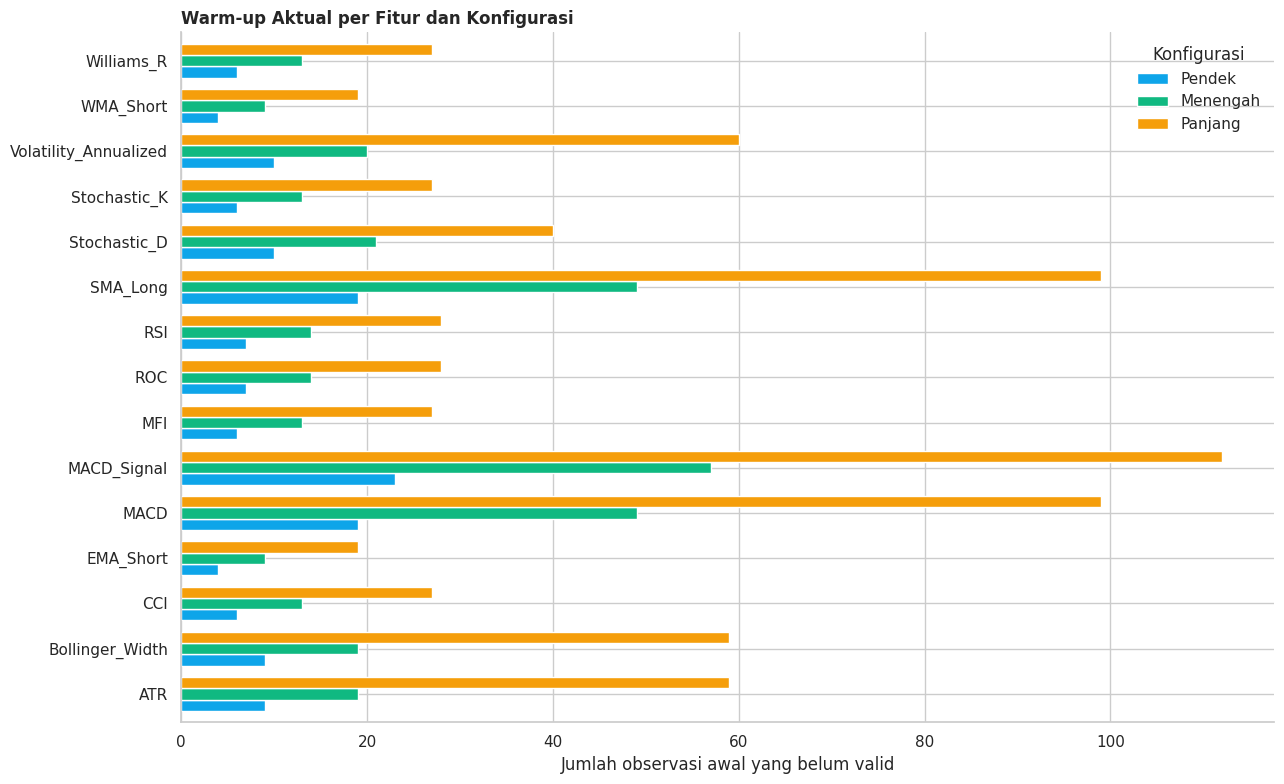

In [15]:
# 13. Visualisasi warm-up
plot_warmup = warmup_analysis.pivot(
    index="Fitur", columns="Konfigurasi", values="Warmup_Aktual"
)[["Pendek", "Menengah", "Panjang"]]

ax = plot_warmup.plot(
    kind="barh",
    figsize=(13, 8),
    color=[COLORS["Pendek"], COLORS["Menengah"], COLORS["Panjang"]],
    width=0.75,
)
ax.set_title("Warm-up Aktual per Fitur dan Konfigurasi", loc="left", fontweight="bold")
ax.set_xlabel("Jumlah observasi awal yang belum valid")
ax.set_ylabel("")
ax.legend(title="Konfigurasi", frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

## G. Validasi Tiga Konfigurasi

Model pembanding menggunakan regresi logistik karena sederhana dan mudah diaudit. Tujuan utama tahap ini bukan mencari model perdagangan terbaik, tetapi menguji apakah konfigurasi fitur membawa informasi yang stabil. Semua konfigurasi memakai tanggal awal train yang sama. Cross-validation juga menggunakan `gap=1` untuk memisahkan horizon target satu hari dari fold berikutnya.

**Metrik utama:** balanced accuracy. Metrik ini memberi bobot seimbang pada kelas naik dan turun. ROC-AUC menjadi metrik pendamping. Akurasi biasa tetap dilaporkan sebagai konteks.

In [16]:
# 12. Fungsi evaluasi konfigurasi tanpa data test
def prepare_train_validation(labeled_frame):
    clean = labeled_frame.dropna(
        subset=FEATURE_NAMES + ["Target_Up_1D"]
    ).copy()
    # Gunakan awal sampel yang sama untuk seluruh konfigurasi.
    # Tanggal terakhir train dipurge karena target t+1 memasuki validation.
    train = clean.loc[
        (clean.index >= common_train_start_date)
        & (clean.index < train_end_date)
    ]
    valid = clean.loc[
        (clean.index > train_end_date)
        & (clean.index <= validation_end_date)
    ]

    if train.empty or valid.empty:
        raise ValueError("Train atau validation kosong setelah warm-up.")
    if train.index.max() >= valid.index.min():
        raise AssertionError("Urutan waktu train-validation tidak valid.")

    x_train = train[FEATURE_NAMES]
    y_train = train["Target_Up_1D"].astype(int)
    x_valid = valid[FEATURE_NAMES]
    y_valid = valid["Target_Up_1D"].astype(int)
    return x_train, y_train, x_valid, y_valid


def make_model():
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "model",
                LogisticRegression(
                    C=1.0,
                    penalty="l2",
                    class_weight="balanced",
                    max_iter=3000,
                    solver="lbfgs",
                    random_state=RANDOM_STATE,
                ),
            ),
        ]
    )


def safe_auc(y_true, probabilities):
    if pd.Series(y_true).nunique() < 2:
        return np.nan
    return roc_auc_score(y_true, probabilities)


def evaluate_configuration(config_name, labeled_frame, n_splits=5):
    x_train, y_train, x_valid, y_valid = prepare_train_validation(
        labeled_frame
    )

    # gap=1 mencegah target t+1 pada fold train bertumpang tindih
    # dengan awal fold evaluasi.
    splitter = TimeSeriesSplit(n_splits=n_splits, gap=1)
    scoring = {
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc": "roc_auc",
        "accuracy": "accuracy",
    }
    cv = cross_validate(
        make_model(),
        x_train,
        y_train,
        cv=splitter,
        scoring=scoring,
        error_score="raise",
    )

    fitted = make_model().fit(x_train, y_train)
    valid_pred = fitted.predict(x_valid)
    valid_prob = fitted.predict_proba(x_valid)[:, 1]

    return {
        "Konfigurasi": config_name,
        "N_Train": len(x_train),
        "N_Validation": len(x_valid),
        "CV_Balanced_Accuracy_Mean": cv["test_balanced_accuracy"].mean(),
        "CV_Balanced_Accuracy_SD": cv["test_balanced_accuracy"].std(ddof=1),
        "CV_ROC_AUC_Mean": cv["test_roc_auc"].mean(),
        "CV_ROC_AUC_SD": cv["test_roc_auc"].std(ddof=1),
        "CV_Accuracy_Mean": cv["test_accuracy"].mean(),
        "Validation_Balanced_Accuracy": balanced_accuracy_score(
            y_valid, valid_pred
        ),
        "Validation_ROC_AUC": safe_auc(y_valid, valid_prob),
        "Validation_Accuracy": accuracy_score(y_valid, valid_pred),
        "Validation_TN": confusion_matrix(
            y_valid, valid_pred, labels=[0, 1]
        )[0, 0],
        "Validation_FP": confusion_matrix(
            y_valid, valid_pred, labels=[0, 1]
        )[0, 1],
        "Validation_FN": confusion_matrix(
            y_valid, valid_pred, labels=[0, 1]
        )[1, 0],
        "Validation_TP": confusion_matrix(
            y_valid, valid_pred, labels=[0, 1]
        )[1, 1],
    }

OUTPUT TAHAP L: hasil cross-validation dan validation


,Konfigurasi,N_Train,N_Validation,CV_Balanced_Accuracy_Mean,CV_Balanced_Accuracy_SD,CV_ROC_AUC_Mean,CV_ROC_AUC_SD,CV_Accuracy_Mean,Validation_Balanced_Accuracy,Validation_ROC_AUC,Validation_Accuracy,Validation_TN,Validation_FP,Validation_FN,Validation_TP
0,Menengah,2700,602,0.4998,0.0245,0.5065,0.0342,0.4844,0.5169,0.5228,0.4801,265,11,302,24
1,Panjang,2700,602,0.5146,0.0193,0.5204,0.0355,0.5000,0.5003,0.5074,0.4684,244,32,288,38
2,Pendek,2700,602,0.5081,0.0195,0.5205,0.0287,0.4876,0.4993,0.5156,0.4668,246,30,291,35


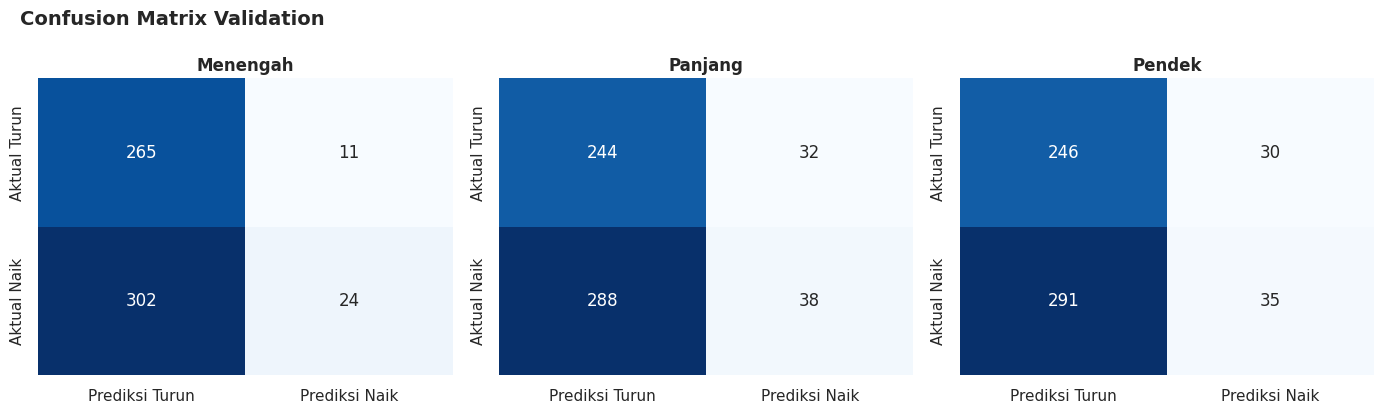

In [17]:
# 15. Jalankan evaluasi tiga konfigurasi
evaluation_records = []
for config_name, labeled_frame in feature_frames.items():
    evaluation_records.append(
        evaluate_configuration(config_name, labeled_frame)
    )

configuration_results = pd.DataFrame(evaluation_records)
configuration_results = configuration_results.sort_values(
    "Validation_Balanced_Accuracy", ascending=False
).reset_index(drop=True)
print("OUTPUT TAHAP L: hasil cross-validation dan validation")
display(configuration_results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(14, 4.2))
for ax, row in zip(axes, configuration_results.to_dict("records")):
    cm = np.array(
        [
            [row["Validation_TN"], row["Validation_FP"]],
            [row["Validation_FN"], row["Validation_TP"]],
        ]
    )
    sns.heatmap(
        cm, annot=True, fmt=".0f", cmap="Blues", cbar=False,
        xticklabels=["Prediksi Turun", "Prediksi Naik"],
        yticklabels=["Aktual Turun", "Aktual Naik"],
        ax=ax,
    )
    ax.set_title(row["Konfigurasi"], fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("")
fig.suptitle(
    "Confusion Matrix Validation",
    x=0.02, ha="left", fontweight="bold", fontsize=14
)
plt.tight_layout()
plt.show()

## H. Audit Redundansi Fitur

Redundansi dinilai melalui tiga pemeriksaan pada train:

- **Korelasi absolut ≥ 0,90:** dua fitur bergerak hampir sama secara linear.
- **VIF > 10:** satu fitur banyak dijelaskan oleh kombinasi fitur lain.
- **Fitur konstan:** fitur tidak membawa variasi.

Korelasi tinggi tidak otomatis berarti sebuah fitur salah. Namun, mempertahankan terlalu banyak transformasi yang serupa dapat memperbesar multikolinearitas, menurunkan kestabilan koefisien, dan meningkatkan kompleksitas tanpa informasi tambahan.

OUTPUT TAHAP M: ringkasan risiko redundansi


,Konfigurasi,Pasangan_Korelasi_Tinggi,Fitur_VIF_di_atas_10,VIF_Maksimum,Fitur_Konstan
0,Pendek,7,8,59150.65,0
1,Menengah,7,8,31595.56,0
2,Panjang,7,8,12509.79,0


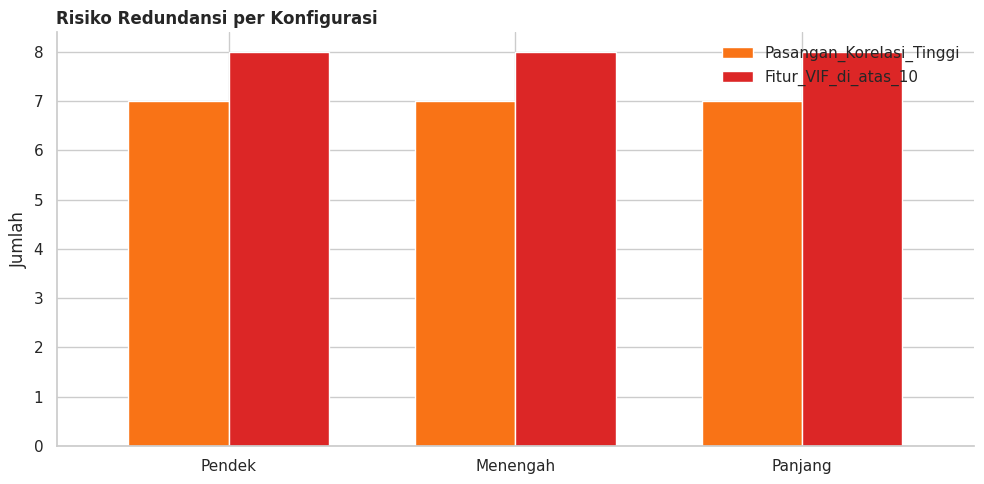

In [18]:
# 16. Fungsi korelasi dan VIF
def correlation_pairs(x, threshold=CORRELATION_THRESHOLD):
    corr = x.corr()
    records = []
    for i, left in enumerate(corr.columns):
        for j in range(i + 1, len(corr.columns)):
            right = corr.columns[j]
            value = corr.iloc[i, j]
            if pd.notna(value) and abs(value) >= threshold:
                records.append(
                    {
                        "Fitur_1": left,
                        "Fitur_2": right,
                        "Korelasi": value,
                        "Korelasi_Absolut": abs(value),
                        "Risiko": "Tinggi",
                    }
                )
    columns = [
        "Fitur_1",
        "Fitur_2",
        "Korelasi",
        "Korelasi_Absolut",
        "Risiko",
    ]
    return pd.DataFrame(records, columns=columns).sort_values(
        "Korelasi_Absolut", ascending=False
    ) if records else pd.DataFrame(columns=columns)


def calculate_vif(x):
    complete = x.dropna().copy()
    if len(complete) < max(100, len(x.columns) * 5):
        raise ValueError("Observasi tidak cukup untuk menghitung VIF.")

    scaler = StandardScaler()
    standardized = scaler.fit_transform(complete)
    records = []

    for idx, feature in enumerate(complete.columns):
        y = standardized[:, idx]
        others = np.delete(standardized, idx, axis=1)
        r_squared = LinearRegression().fit(others, y).score(others, y)
        vif = np.inf if r_squared >= 1 - 1e-12 else 1 / (1 - r_squared)
        if vif > 10:
            risk = "Tinggi"
        elif vif > 5:
            risk = "Sedang"
        else:
            risk = "Rendah"
        records.append(
            {
                "Fitur": feature,
                "R_Squared_dari_Fitur_Lain": r_squared,
                "VIF": vif,
                "Risiko_VIF": risk,
            }
        )
    return pd.DataFrame(records).sort_values("VIF", ascending=False)


redundancy_by_config = {}
redundancy_summary_records = []

for config_name, labeled_frame in feature_frames.items():
    x_train, _, _, _ = prepare_train_validation(labeled_frame)
    pairs = correlation_pairs(x_train)
    vif = calculate_vif(x_train)
    constant_features = [
        col for col in FEATURE_NAMES if x_train[col].nunique() <= 1
    ]

    redundancy_by_config[config_name] = {
        "pairs": pairs,
        "vif": vif,
        "constant_features": constant_features,
    }
    redundancy_summary_records.append(
        {
            "Konfigurasi": config_name,
            "Pasangan_Korelasi_Tinggi": len(pairs),
            "Fitur_VIF_di_atas_10": int((vif["VIF"] > 10).sum()),
            "VIF_Maksimum": vif["VIF"].replace(np.inf, np.nan).max(),
            "Fitur_Konstan": len(constant_features),
        }
    )

redundancy_summary = pd.DataFrame(redundancy_summary_records)
print("OUTPUT TAHAP M: ringkasan risiko redundansi")
display(redundancy_summary.round(2))

redundancy_plot = redundancy_summary.set_index("Konfigurasi")[
    ["Pasangan_Korelasi_Tinggi", "Fitur_VIF_di_atas_10"]
]
ax = redundancy_plot.plot(
    kind="bar",
    figsize=(10, 5),
    color=["#F97316", "#DC2626"],
    width=0.7,
)
ax.set_title(
    "Risiko Redundansi per Konfigurasi",
    loc="left", fontweight="bold"
)
ax.set_xlabel("")
ax.set_ylabel("Jumlah")
ax.tick_params(axis="x", rotation=0)
ax.legend(frameon=False)
sns.despine()
plt.tight_layout()
plt.show()

In [19]:
# 17. Gabungkan metrik dan pilih konfigurasi
ranking_table = (
    configuration_results
    .merge(
        redundancy_summary,
        on="Konfigurasi",
        how="left",
        validate="one_to_one",
    )
    .merge(
        warmup_summary[
            [
                "Konfigurasi",
                "Warmup_Maksimum",
                "Persen_Hilang_Maks",
            ]
        ],
        on="Konfigurasi",
        how="left",
        validate="one_to_one",
    )
)

# Urutan keputusan transparan, tanpa bobot arbitrer.
ranking_table = ranking_table.sort_values(
    by=[
        "Validation_Balanced_Accuracy",
        "Validation_ROC_AUC",
        "Pasangan_Korelasi_Tinggi",
        "Warmup_Maksimum",
    ],
    ascending=[False, False, True, True],
).reset_index(drop=True)
ranking_table.insert(0, "Peringkat", np.arange(1, len(ranking_table) + 1))

selected_config_name = ranking_table.loc[0, "Konfigurasi"]
selected_config = WINDOW_CONFIGS[selected_config_name]

print("OUTPUT TAHAP N: peringkat dan konfigurasi terpilih")
print(f"Konfigurasi terpilih: {selected_config_name}")
print(
    "Dasar: balanced accuracy validation, ROC-AUC, redundansi, lalu warm-up."
)
display(ranking_table.round(4))

OUTPUT TAHAP N: peringkat dan konfigurasi terpilih
Konfigurasi terpilih: Menengah
Dasar: balanced accuracy validation, ROC-AUC, redundansi, lalu warm-up.


,Peringkat,Konfigurasi,N_Train,N_Validation,CV_Balanced_Accuracy_Mean,CV_Balanced_Accuracy_SD,CV_ROC_AUC_Mean,CV_ROC_AUC_SD,CV_Accuracy_Mean,Validation_Balanced_Accuracy,Validation_ROC_AUC,Validation_Accuracy,Validation_TN,Validation_FP,Validation_FN,Validation_TP,Pasangan_Korelasi_Tinggi,Fitur_VIF_di_atas_10,VIF_Maksimum,Fitur_Konstan,Warmup_Maksimum,Persen_Hilang_Maks
0,1,Menengah,2700,602,0.4998,0.0245,0.5065,0.0342,0.4844,0.5169,0.5228,0.4801,265,11,302,24,7,8,31595.5558,0,57,1.6686
1,2,Panjang,2700,602,0.5146,0.0193,0.5204,0.0355,0.5000,0.5003,0.5074,0.4684,244,32,288,38,7,8,12509.7873,0,112,3.2787
2,3,Pendek,2700,602,0.5081,0.0195,0.5205,0.0287,0.4876,0.4993,0.5156,0.4668,246,30,291,35,7,8,59150.6493,0,23,0.6733


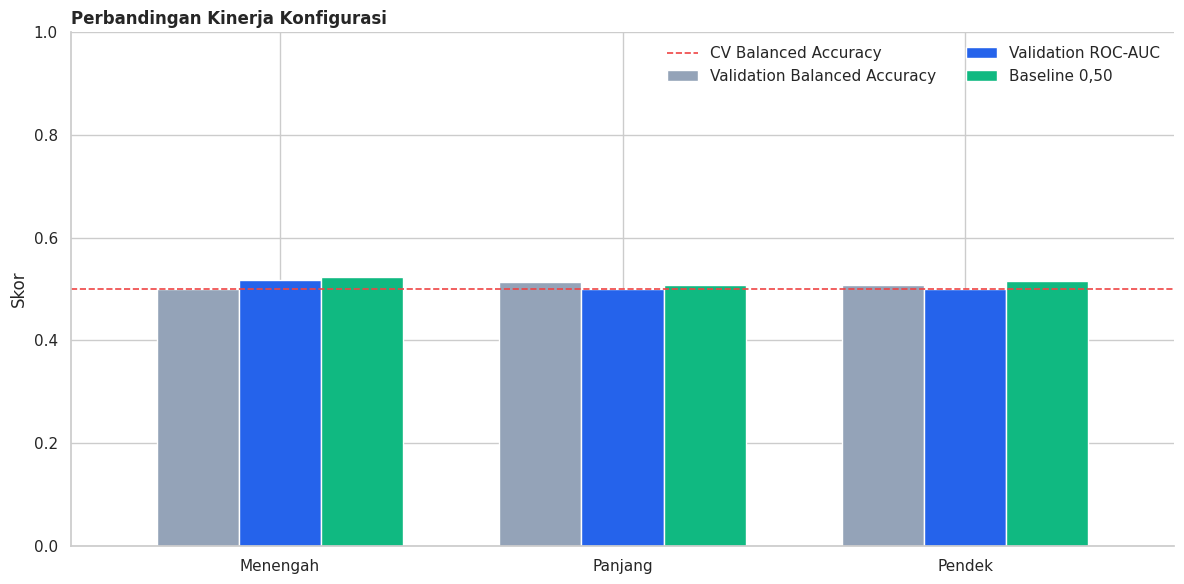

In [20]:
# 18. Visualisasi perbandingan performa
metrics_plot = ranking_table.set_index("Konfigurasi")[
    [
        "CV_Balanced_Accuracy_Mean",
        "Validation_Balanced_Accuracy",
        "Validation_ROC_AUC",
    ]
]

ax = metrics_plot.plot(
    kind="bar",
    figsize=(12, 6),
    color=["#94A3B8", "#2563EB", "#10B981"],
    width=0.72,
)
ax.axhline(0.50, color="#EF4444", ls="--", lw=1.2, label="Baseline 0,50")
ax.set_ylim(0, 1)
ax.set_title("Perbandingan Kinerja Konfigurasi", loc="left", fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Skor")
ax.legend(
    [
        "CV Balanced Accuracy",
        "Validation Balanced Accuracy",
        "Validation ROC-AUC",
        "Baseline 0,50",
    ],
    frameon=False,
    ncol=2,
)
ax.tick_params(axis="x", rotation=0)
sns.despine()
plt.tight_layout()
plt.show()

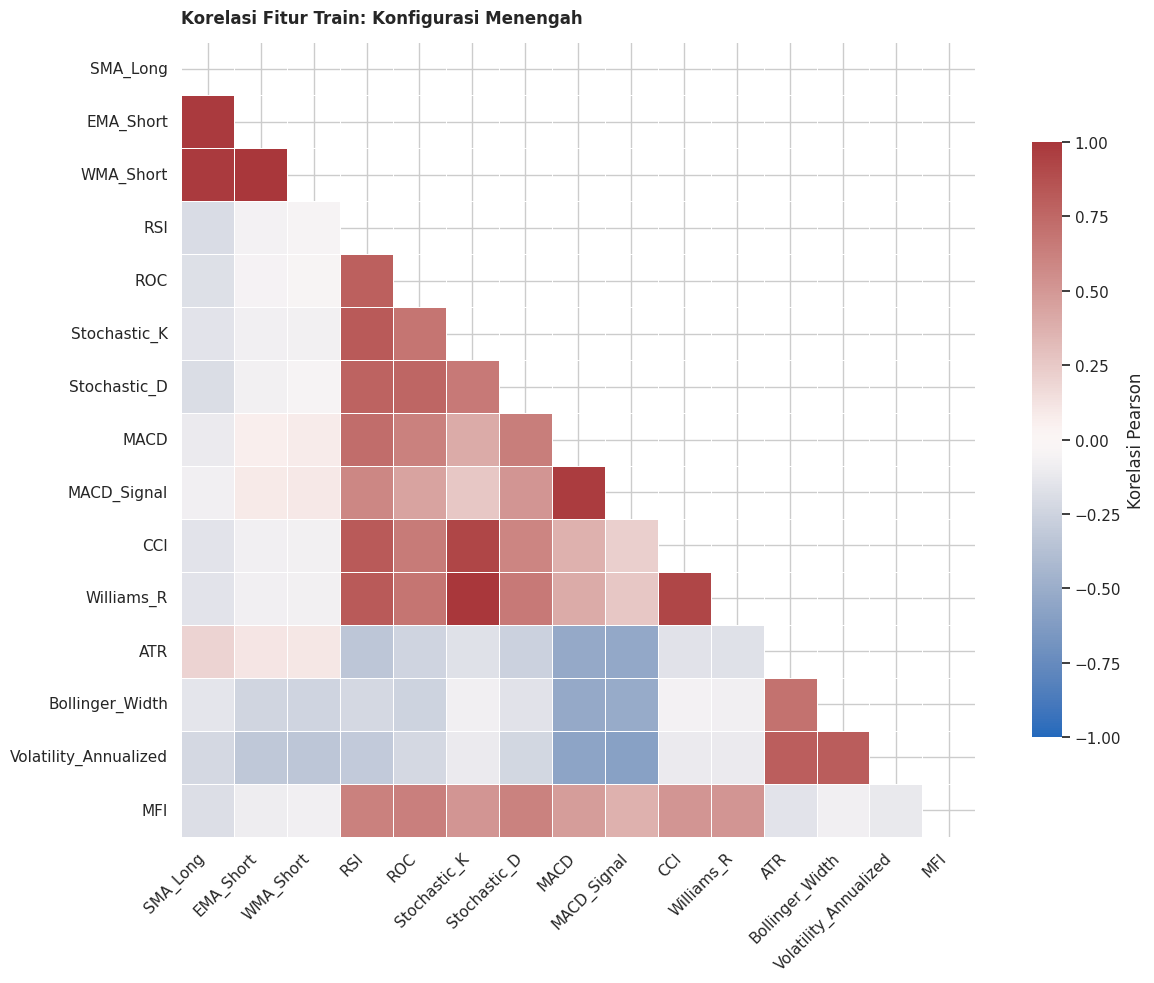

,Fitur_1,Fitur_2,Korelasi,Korelasi_Absolut,Risiko
4,Stochastic_K,Williams_R,1.000000,1.000000,Tinggi
2,EMA_Short,WMA_Short,0.999773,0.999773,Tinggi
0,SMA_Long,EMA_Short,0.983433,0.983433,Tinggi
1,SMA_Long,WMA_Short,0.980256,0.980256,Tinggi
5,MACD,MACD_Signal,0.972090,0.972090,Tinggi
3,Stochastic_K,CCI,0.922392,0.922392,Tinggi
6,CCI,Williams_R,0.922392,0.922392,Tinggi


,Fitur,R_Squared_dari_Fitur_Lain,VIF,Risiko_VIF
5,Stochastic_K,1.000,inf,Tinggi
10,Williams_R,1.000,inf,Tinggi
1,EMA_Short,1.000,31595.556,Tinggi
2,WMA_Short,1.000,29529.026,Tinggi
0,SMA_Long,0.999,813.772,Tinggi
7,MACD,0.996,249.444,Tinggi
8,MACD_Signal,0.993,144.273,Tinggi
3,RSI,0.926,13.563,Tinggi
9,CCI,0.893,9.326,Sedang
13,Volatility_Annualized,0.878,8.183,Sedang


In [21]:
# 19. Heatmap korelasi konfigurasi terpilih
selected_labeled = feature_frames[selected_config_name]
selected_x_train, _, selected_x_valid, _ = prepare_train_validation(
    selected_labeled
)
selected_corr = selected_x_train.corr()

mask = np.triu(np.ones_like(selected_corr, dtype=bool))
fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    selected_corr,
    mask=mask,
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.75, "label": "Korelasi Pearson"},
    ax=ax,
)
ax.set_title(
    f"Korelasi Fitur Train: Konfigurasi {selected_config_name}",
    loc="left",
    fontweight="bold",
    pad=14,
)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

display(redundancy_by_config[selected_config_name]["pairs"].head(20))
display(redundancy_by_config[selected_config_name]["vif"].head(15).round(3))

## I. Analisis Kritis dan Logika Keputusan

Interpretasi harus memisahkan **kemampuan deskriptif** dan **kemampuan prediktif**. Indikator teknikal hanya mengubah data harga dan volume historis. Indikator tidak membuktikan penyebab pergerakan IHSG.

In [22]:
# 20. Ringkasan analitis otomatis
best_row = ranking_table.iloc[0]
best_pairs = redundancy_by_config[selected_config_name]["pairs"]
best_vif = redundancy_by_config[selected_config_name]["vif"]

validation_edge = best_row["Validation_Balanced_Accuracy"] - 0.50
if validation_edge >= 0.05:
    performance_note = (
        "Skor validation berada cukup jauh di atas baseline 0,50. "
        "Hasil tetap memerlukan pengujian test satu kali."
    )
elif validation_edge > 0:
    performance_note = (
        "Skor validation hanya sedikit di atas baseline 0,50. "
        "Keunggulan prediktif masih lemah dan sensitif terhadap biaya transaksi."
    )
else:
    performance_note = (
        "Skor validation tidak melampaui baseline 0,50. "
        "Fitur belum menunjukkan kemampuan klasifikasi arah yang meyakinkan."
    )

highest_vif_feature = best_vif.iloc[0]["Fitur"]
highest_vif_value = best_vif.iloc[0]["VIF"]
pair_text = (
    f"{best_pairs.iloc[0]['Fitur_1']} dan {best_pairs.iloc[0]['Fitur_2']}"
    if not best_pairs.empty
    else "tidak ada pasangan"
)

analysis_text = f'''
HASIL SELEKSI KONFIGURASI
Konfigurasi terpilih: {selected_config_name}
Window: {selected_config}
Balanced accuracy validation: {best_row["Validation_Balanced_Accuracy"]:.4f}
ROC-AUC validation: {best_row["Validation_ROC_AUC"]:.4f}
Warm-up maksimum: {int(best_row["Warmup_Maksimum"])} observasi
Pasangan korelasi tinggi: {int(best_row["Pasangan_Korelasi_Tinggi"])}

INTERPRETASI
{performance_note}
Pasangan redundan terkuat adalah {pair_text}.
VIF tertinggi dimiliki {highest_vif_feature} sebesar {highest_vif_value:.2f}.

RISIKO UTAMA
1. Moving average dan MACD dapat menyampaikan informasi tren yang sama.
2. Stochastic_K dan Williams_R secara matematis hampir merupakan transformasi linear.
3. Window pendek lebih responsif, tetapi mudah menangkap noise dan meningkatkan turnover.
4. Window panjang lebih stabil, tetapi menambah lag dan mengurangi sampel efektif.
5. Kinerja klasifikasi belum memasukkan biaya transaksi, slippage, dan aturan eksekusi.
6. Perubahan rezim pasar dapat membuat konfigurasi historis tidak stabil.

REKOMENDASI
Gunakan konfigurasi terpilih sebagai kandidat, bukan bukti final.
Tinjau penghapusan salah satu fitur pada pasangan yang sangat berkorelasi.
Bekukan pipeline, hiperparameter, dan aturan keputusan sebelum membuka test.
'''
print("OUTPUT TAHAP O: analisis kritis")
print(analysis_text)

critical_review = pd.DataFrame(
    [
        (
            "Validitas prediktif",
            f"Balanced accuracy validation = {best_row['Validation_Balanced_Accuracy']:.4f}",
            performance_note,
            "Uji test satu kali setelah keputusan dibekukan",
        ),
        (
            "Redundansi",
            f"{int(best_row['Pasangan_Korelasi_Tinggi'])} pasangan memiliki |r| ≥ {CORRELATION_THRESHOLD:.2f}",
            "Koefisien dapat tidak stabil dan interpretasi fitur dapat berulang",
            "Pertimbangkan satu wakil dari kelompok fitur yang setara",
        ),
        (
            "Warm-up",
            f"{int(best_row['Warmup_Maksimum'])} baris awal hilang",
            "Window panjang mengurangi sampel efektif dan menambah lag",
            "Bandingkan semua konfigurasi pada tanggal awal yang sama",
        ),
        (
            "Kausalitas",
            "Fitur hanya memakai data sampai waktu t",
            "Indikator tetap bukan penyebab gerak harga",
            "Gunakan bahasa asosiasi atau prediksi, bukan kausalitas",
        ),
        (
            "Implementasi finansial",
            "Metrik belum memasukkan biaya transaksi",
            "Keunggulan statistik belum tentu menghasilkan laba bersih",
            "Tambahkan turnover, fee, slippage, dan drawdown pada studi lanjutan",
        ),
    ],
    columns=["Dimensi", "Bukti", "Makna Kritis", "Tindakan"],
)
display(critical_review)

OUTPUT TAHAP O: analisis kritis

HASIL SELEKSI KONFIGURASI
Konfigurasi terpilih: Menengah
Window: {'trend_short': 10, 'trend_long': 50, 'momentum': 14, 'volatility': 20, 'signal': 9}
Balanced accuracy validation: 0.5169
ROC-AUC validation: 0.5228
Warm-up maksimum: 57 observasi
Pasangan korelasi tinggi: 7

INTERPRETASI
Skor validation hanya sedikit di atas baseline 0,50. Keunggulan prediktif masih lemah dan sensitif terhadap biaya transaksi.
Pasangan redundan terkuat adalah Stochastic_K dan Williams_R.
VIF tertinggi dimiliki Stochastic_K sebesar inf.

RISIKO UTAMA
1. Moving average dan MACD dapat menyampaikan informasi tren yang sama.
2. Stochastic_K dan Williams_R secara matematis hampir merupakan transformasi linear.
3. Window pendek lebih responsif, tetapi mudah menangkap noise dan meningkatkan turnover.
4. Window panjang lebih stabil, tetapi menambah lag dan mengurangi sampel efektif.
5. Kinerja klasifikasi belum memasukkan biaya transaksi, slippage, dan aturan eksekusi.
6. Perubaha

,Dimensi,Bukti,Makna Kritis,Tindakan
0,Validitas prediktif,Balanced accuracy validation = 0.5169,"Skor validation hanya sedikit di atas baseline 0,50. Keunggulan prediktif masih lemah dan sensitif terhadap biaya tr...",Uji test satu kali setelah keputusan dibekukan
1,Redundansi,7 pasangan memiliki |r| ≥ 0.90,Koefisien dapat tidak stabil dan interpretasi fitur dapat berulang,Pertimbangkan satu wakil dari kelompok fitur yang setara
2,Warm-up,57 baris awal hilang,Window panjang mengurangi sampel efektif dan menambah lag,Bandingkan semua konfigurasi pada tanggal awal yang sama
3,Kausalitas,Fitur hanya memakai data sampai waktu t,Indikator tetap bukan penyebab gerak harga,"Gunakan bahasa asosiasi atau prediksi, bukan kausalitas"
4,Implementasi finansial,Metrik belum memasukkan biaya transaksi,Keunggulan statistik belum tentu menghasilkan laba bersih,"Tambahkan turnover, fee, slippage, dan drawdown pada studi lanjutan"


## J. Pemeriksaan Bug dan Risiko Logika

| Risiko | Gejala | Pencegahan dalam notebook |
|---|---|---|
| Look-ahead bias | Fitur memakai informasi masa depan | Rolling selalu ke belakang, unit test mengubah baris terakhir |
| Data leakage | Scaler belajar dari validation/test | Scaler berada dalam pipeline dan fit hanya pada train/fold |
| Random split | Masa depan masuk train | Split kronologis dan `TimeSeriesSplit` |
| Target leakage | Return hari yang sama masuk fitur | Target memakai log return \(t+1\) |
| Backfill | Nilai awal diisi dari masa depan | Tidak menggunakan `bfill` |
| Infinite value | Pembagian dengan nol | `safe_divide` dan penggantian infinity ke NaN |
| Salah OHLC | High/Low tidak konsisten | Validasi relasi High, Low, Open, Close |
| Duplikasi tanggal | Satu hari dihitung dua kali | Indeks diurutkan dan dideduplikasi |
| Warm-up diabaikan | Sampel antarwindow tidak sebanding | Tabel warm-up aktual dan ukuran sampel dilaporkan |
| Multikolinearitas | Koefisien tidak stabil | Audit korelasi dan VIF pada train |
| Data test tersentuh | Hasil terlalu optimistis | `TEST_UNLOCKED=False` secara default |

In [23]:
# 21. Pemeriksaan integritas akhir sebelum ekspor
assert selected_config_name in WINDOW_CONFIGS
assert set(ranking_table["Konfigurasi"]) == set(WINDOW_CONFIGS)
assert ranking_table["N_Train"].min() > 0
assert ranking_table["N_Validation"].min() > 0
assert not ranking_table[
    [
        "Validation_Balanced_Accuracy",
        "Validation_ROC_AUC",
        "CV_Balanced_Accuracy_Mean",
    ]
].isna().any().any()
assert TEST_UNLOCKED is False
assert development_raw.index.max() < test_vault.index.min()

integrity_results = pd.DataFrame(
    {
        "Pemeriksaan": [
            "Tiga konfigurasi tersedia",
            "Sampel train tersedia",
            "Sampel validation tersedia",
            "Metrik utama lengkap",
            "Urutan development sebelum test",
            "Test Vault terkunci",
        ],
        "Status": ["LULUS"] * 6,
    }
)
print("OUTPUT TAHAP P: pemeriksaan integritas akhir")
display(integrity_results)
print("Semua pemeriksaan integritas lulus. Data test tetap terkunci.")

OUTPUT TAHAP P: pemeriksaan integritas akhir


,Pemeriksaan,Status
0,Tiga konfigurasi tersedia,LULUS
1,Sampel train tersedia,LULUS
2,Sampel validation tersedia,LULUS
3,Metrik utama lengkap,LULUS
4,Urutan development sebelum test,LULUS
5,Test Vault terkunci,LULUS


Semua pemeriksaan integritas lulus. Data test tetap terkunci.


In [24]:
# 22. Ekspor seluruh luaran ke Kaggle Working
kaggle_working = Path("/kaggle/working")
output_dir = (
    kaggle_working / "ihsg_feature_study"
    if kaggle_working.exists()
    else Path.cwd() / "ihsg_feature_study"
)
output_dir.mkdir(parents=True, exist_ok=True)

data_dictionary.to_csv(
    output_dir / "data_dictionary_15_fitur.csv",
    index=False,
)
warmup_analysis.to_csv(
    output_dir / "analisis_warmup_lengkap.csv",
    index=False,
)
warmup_summary.to_csv(
    output_dir / "ringkasan_warmup.csv",
    index=False,
)
ranking_table.to_csv(
    output_dir / "perbandingan_konfigurasi.csv",
    index=False,
)
redundancy_summary.to_csv(
    output_dir / "ringkasan_redundansi.csv",
    index=False,
)

for config_name, reports in redundancy_by_config.items():
    slug = config_name.lower()
    reports["pairs"].to_csv(
        output_dir / f"pasangan_korelasi_{slug}.csv",
        index=False,
    )
    reports["vif"].to_csv(
        output_dir / f"vif_{slug}.csv",
        index=False,
    )

selected_labeled.to_csv(
    output_dir / "fitur_development_konfigurasi_terpilih.csv",
    index=True,
    index_label="Date",
)
(output_dir / "laporan_risiko_redundansi.txt").write_text(
    analysis_text,
    encoding="utf-8",
)

output_files = pd.DataFrame(
    [
        {
            "Nama_File": path.name,
            "Ukuran_KB": round(path.stat().st_size / 1024, 2),
            "Lokasi": str(path),
        }
        for path in sorted(output_dir.iterdir())
        if path.is_file()
    ]
)
print("OUTPUT TAHAP Q: daftar luaran tersimpan")
display(output_files)

OUTPUT TAHAP Q: daftar luaran tersimpan


,Nama_File,Ukuran_KB,Lokasi
0,analisis_warmup_lengkap.csv,1.67,/kaggle/working/ihsg_feature_study/analisis_warmup_lengkap.csv
1,data_dictionary_15_fitur.csv,4.10,/kaggle/working/ihsg_feature_study/data_dictionary_15_fitur.csv
2,fitur_development_konfigurasi_terpilih.csv,1041.01,/kaggle/working/ihsg_feature_study/fitur_development_konfigurasi_terpilih.csv
3,laporan_risiko_redundansi.txt,1.23,/kaggle/working/ihsg_feature_study/laporan_risiko_redundansi.txt
4,pasangan_korelasi_menengah.csv,0.45,/kaggle/working/ihsg_feature_study/pasangan_korelasi_menengah.csv
5,pasangan_korelasi_panjang.csv,0.48,/kaggle/working/ihsg_feature_study/pasangan_korelasi_panjang.csv
6,pasangan_korelasi_pendek.csv,0.48,/kaggle/working/ihsg_feature_study/pasangan_korelasi_pendek.csv
7,perbandingan_konfigurasi.csv,1.03,/kaggle/working/ihsg_feature_study/perbandingan_konfigurasi.csv
8,ringkasan_redundansi.csv,0.18,/kaggle/working/ihsg_feature_study/ringkasan_redundansi.csv
9,ringkasan_warmup.csv,0.29,/kaggle/working/ihsg_feature_study/ringkasan_warmup.csv


## K. Data Test Tetap Terkunci

Sel berikut **tidak mengevaluasi data test** selama `FINAL_EVALUATION = False`. Buka test hanya satu kali setelah kelompok menyetujui konfigurasi final, fitur yang dipertahankan, model, dan metrik.

In [25]:
# 23. Evaluasi final opsional. Default aman: TIDAK DIJALANKAN.
FINAL_EVALUATION = False

if not FINAL_EVALUATION:
    test_status = pd.DataFrame(
        {
            "Komponen": ["Test Vault", "Konfigurasi final", "Evaluasi final"],
            "Status": [
                "TERKUNCI",
                selected_config_name,
                "Belum dijalankan",
            ],
            "Alasan": [
                "Mencegah kebocoran dan optimisme semu",
                "Dipilih hanya dari train dan validation",
                "Menunggu keputusan kelompok dibekukan",
            ],
        }
    )
    print(
        "TEST VAULT TETAP TERKUNCI. "
        "Set FINAL_EVALUATION=True hanya setelah seluruh keputusan dibekukan."
    )
    display(test_status)
else:
    TEST_UNLOCKED = True

    # Fitur test dihitung hanya setelah konfigurasi final dibekukan.
    final_features = build_technical_features(raw_data, selected_config)
    final_labeled = add_prediction_target(
        final_features, raw_data["Close"]
    ).dropna(subset=FEATURE_NAMES + ["Target_Up_1D"])

    development_final = final_labeled.loc[
        final_labeled.index < validation_end_date
    ]
    test_final = final_labeled.loc[
        final_labeled.index > validation_end_date
    ]

    final_model = make_model().fit(
        development_final[FEATURE_NAMES],
        development_final["Target_Up_1D"].astype(int),
    )
    test_pred = final_model.predict(test_final[FEATURE_NAMES])
    test_prob = final_model.predict_proba(
        test_final[FEATURE_NAMES]
    )[:, 1]
    y_test = test_final["Target_Up_1D"].astype(int)

    final_test_result = pd.DataFrame(
        {
            "Konfigurasi": [selected_config_name],
            "N_Test": [len(test_final)],
            "Test_Balanced_Accuracy": [
                balanced_accuracy_score(y_test, test_pred)
            ],
            "Test_ROC_AUC": [safe_auc(y_test, test_prob)],
            "Test_Accuracy": [accuracy_score(y_test, test_pred)],
        }
    )
    display(final_test_result.round(4))
    final_test_result.to_csv(
        output_dir / "hasil_test_final_satu_kali.csv",
        index=False,
    )

TEST VAULT TETAP TERKUNCI. Set FINAL_EVALUATION=True hanya setelah seluruh keputusan dibekukan.


,Komponen,Status,Alasan
0,Test Vault,TERKUNCI,Mencegah kebocoran dan optimisme semu
1,Konfigurasi final,Menengah,Dipilih hanya dari train dan validation
2,Evaluasi final,Belum dijalankan,Menunggu keputusan kelompok dibekukan


## L. Cara Menjalankan di Kaggle

1. Buka [Kaggle Code](https://www.kaggle.com/code) dan pilih **New Notebook**.
2. Unggah file `.ipynb` ini melalui **File → Import Notebook**.
3. Jika memakai unduhan otomatis, aktifkan **Internet** pada **Notebook options**.
4. Jika Internet tidak tersedia, tambahkan dataset CSV IHSG melalui **Add Input**, lalu isi `CSV_PATH`.
5. Pilih **Run All**.
6. Unduh hasil pada panel **Output** di folder `ihsg_feature_study`.
7. Jangan mengubah `FINAL_EVALUATION` sebelum seluruh keputusan model dibekukan.

**Sumber teknis:**

- Dokumentasi yfinance: https://ranaroussi.github.io/yfinance/
- Dokumentasi Kaggle Notebook: https://www.kaggle.com/docs/notebooks
- Sumber data pasar: Yahoo Finance, ticker `^JKSE`